In [1]:
### Hayden Gallo
### Bucci Lab
### 8/28/25
### Testing AD mouse data with gLV-FBA

import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
import sys
import os
import openpyxl
import gurobipy

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess
import re
### script for running glv_dfba inference
from helper_functions import *
import argparse
import re

from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import json
import logging
from scipy.stats import pearsonr, spearmanr
import matplotlib.lines as lines
import matplotlib.patches as mpatches


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#################################################################################################################################################################
### this is used to surpress all logging from loading in the kbase models with cobra, such that they don't get added to the glv_fba log file and overcrowd it ### 
logging.getLogger("cobra").setLevel(logging.ERROR)
#################################################################################################################################################################

In [4]:
### load in the metabolite translation document 

exp_mets_to_kbase_mets = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/exp_mets_to_Kbase_mets.csv', header = None, index_col=0)
exp_mets_to_kbase_mets.head()


,1,2,3,4,5,6,7,8,9,10,...,48,49,50,51,52,53,54,55,56,57
0,,,,,,,,,,,,,,,,,,,,,
Sample C(nmol/g),3-(3-hydroxyphenyl) propionic acid (3-HPPA),3-(4-hydroxyphenyl)lactic acid (HPLA),"3,4-Dihydroxyphenyl ethanol (DOPET)","3,4-Dihydroxyphenyl lactic acid (DHPLA)","3,4-Dihydroxyphenylethhylene glycol (DHPG)","3,4-Dimethoxyphenethylamine",3-Hydroxyanthranilic acid(3-HAA),3-Hydroxykynurenine,3-Methoxytyramine,3-O-Methyl-L-DOPA,...,Phenylpyruvic acid,Pipecolic acid,Serotonin,Synephrine,Tryptophan,Tyramine,Tyrosine,Tyrosine methyl ester,Vanillactic acid,Xanthurenic acid
Kbase,hydracrylic acid,NaN,3-hydroxytryrosol,"R(+)-3,4-dihydroxyphenyllactate","3,4-dihydroxyphenlyethyleneglycol",NaN,3-Hydroxyanthranilate,3-Hydroxykynurenine,3-Methoxytyramine,3-O-methyldopa,...,Phenylpyruvate,L-pipecolate,Serotonin,(-)-Sympatol,L-tryptophan,Tyramine,L-Tyrosine,L-tyrosine methyl ester,3-methoxy-4-hydroxyhenyllactate,Xanthurenate
Kbase cpd num,cpd00745,NaN,cpd32505,cpd24677,cpd03306,NaN,cpd00483,cpd01804,cpd03316,cpd22970,...,cpd00143,cpd00323,cpd00579,cpd01286,cpd00065,cpd00374,cpd00069,cpd02151,cpd23099,cpd01625
sources,NaN,NaN,https://en.wikipedia.org/wiki/Hydroxytyrosol,NaN,https://en.wikipedia.org/wiki/Dihydroxyphenyle...,NaN,https://en.wikipedia.org/wiki/3-Hydroxyanthran...,NaN,NaN,https://en.wikipedia.org/wiki/3-O-Methyldopa,...,NaN,NaN,NaN,NaN,D-trytophan is cpd00411,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
exp_mets_to_kbase_mets = exp_mets_to_kbase_mets.T
exp_mets_to_kbase_mets.columns = ['Exp_name', 'Kbase_name', 'Kbase_cpd_num', 'Sources', 'Notes']
exp_mets_to_kbase_mets.head()



,Exp_name,Kbase_name,Kbase_cpd_num,Sources,Notes
1,3-(3-hydroxyphenyl) propionic acid (3-HPPA),hydracrylic acid,cpd00745,NaN,NaN
2,3-(4-hydroxyphenyl)lactic acid (HPLA),NaN,NaN,NaN,NaN
3,"3,4-Dihydroxyphenyl ethanol (DOPET)",3-hydroxytryrosol,cpd32505,https://en.wikipedia.org/wiki/Hydroxytyrosol,NaN
4,"3,4-Dihydroxyphenyl lactic acid (DHPLA)","R(+)-3,4-dihydroxyphenyllactate",cpd24677,NaN,NaN
5,"3,4-Dihydroxyphenylethhylene glycol (DHPG)","3,4-dihydroxyphenlyethyleneglycol",cpd03306,https://en.wikipedia.org/wiki/Dihydroxyphenyle...,NaN


In [6]:
### filter by kbase_cpd_num, only ones rows that have cpd 
exp_mets_to_kbase_mets = exp_mets_to_kbase_mets.fillna(0)
exp_mets_to_kbase_mets_filt = exp_mets_to_kbase_mets[exp_mets_to_kbase_mets['Kbase_cpd_num'] != 0]
exp_mets_to_kbase_mets_filt.head()

,Exp_name,Kbase_name,Kbase_cpd_num,Sources,Notes
1,3-(3-hydroxyphenyl) propionic acid (3-HPPA),hydracrylic acid,cpd00745,0,0
3,"3,4-Dihydroxyphenyl ethanol (DOPET)",3-hydroxytryrosol,cpd32505,https://en.wikipedia.org/wiki/Hydroxytyrosol,0
4,"3,4-Dihydroxyphenyl lactic acid (DHPLA)","R(+)-3,4-dihydroxyphenyllactate",cpd24677,0,0
5,"3,4-Dihydroxyphenylethhylene glycol (DHPG)","3,4-dihydroxyphenlyethyleneglycol",cpd03306,https://en.wikipedia.org/wiki/Dihydroxyphenyle...,0
7,3-Hydroxyanthranilic acid(3-HAA),3-Hydroxyanthranilate,cpd00483,https://en.wikipedia.org/wiki/3-Hydroxyanthran...,0


In [7]:
cpds_to_filter_for = []

for met in exp_mets_to_kbase_mets_filt['Kbase_cpd_num'].to_list():
    
    temp_met = 'EX_' + met + '_b'
    
    cpds_to_filter_for.append(temp_met)

cpds_to_filter_for


exp_mets_to_kbase_dict = dict(zip(exp_mets_to_kbase_mets_filt['Exp_name'].to_list(), cpds_to_filter_for))
kbase_to_exp_mets_dict = dict(zip(cpds_to_filter_for, exp_mets_to_kbase_mets_filt['Exp_name'].to_list()))
exp_mets_to_kbase_dict



{'3-(3-hydroxyphenyl) propionic acid (3-HPPA)': 'EX_cpd00745_b',
 '3,4-Dihydroxyphenyl ethanol (DOPET)': 'EX_cpd32505_b',
 '3,4-Dihydroxyphenyl lactic acid (DHPLA)': 'EX_cpd24677_b',
 '3,4-Dihydroxyphenylethhylene glycol (DHPG)': 'EX_cpd03306_b',
 '3-Hydroxyanthranilic acid(3-HAA)': 'EX_cpd00483_b',
 '3-Hydroxykynurenine': 'EX_cpd01804_b',
 '3-Methoxytyramine': 'EX_cpd03316_b',
 '3-O-Methyl-L-DOPA': 'EX_cpd22970_b',
 '4-Hydroxyphenylpyruvic acid': 'EX_cpd00868_b',
 '5-Aminovaleric acid': 'EX_cpd00339_b',
 '5-HydroxyIndoleacetic acid(5-HIAA)': 'EX_cpd03346_b',
 '5-Hydroxytryptophol': 'EX_cpd23049_b',
 '5-Methoxytryptamine': 'EX_cpd03370_b',
 'Anthranilic acid(2-aminobenzoic acid)': 'EX_cpd00093_b',
 'D3-(3-hydroxyphenyl) propionic acid': 'EX_cpd08304_b',
 'DOPA': 'EX_cpd00291_b',
 'DOPAC': 'EX_cpd00854_b',
 'Dopamine': 'EX_cpd02357_b',
 'Epinephrine/adrenaline': 'EX_cpd00583_b',
 'Homogentisic acid': 'EX_cpd00426_b',
 'Homovanillic acid': 'EX_cpd03312_b',
 'Indole 3-acetamide': 'EX_cpd0

In [8]:
#### load in experimental metabolomics data

exp_mets = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/AD_mouse_metabolomics_HG_copy.csv', header = 1, index_col=0)
exp_mets.head()

### replace Not detected in column  Indole 3-acetamide

exp_mets['Indole 3-acetamide'] = exp_mets['Indole 3-acetamide'].str.replace('Not detected', '0') 
exp_mets['Indole 3-acetamide']


Sample C(nmol/g)
01_1R5_Fecal               0
02_2R5_Fecal               0
03_5R5_Fecal               0
04_6R5_Fecal               0
05_9R5_Fecal               0
06_10R5_Fecal              0
07_13R5_Fecal              0
08_14R5_Fecal              0
09_17R5_Fecal              0
10_18R5_Fecal              0
11_21R5_Fecal              0
12_22R5_Fecal              0
13_1LC_Lumen contents      0
14_2LC_Lumen contents      0
15_5LC_Lumen contents      0
16_6LC_Lumen contents      0
17_9LC_Lumen contents      0
18_10LC_Lumen contents     0
19_1CT_Large Intestine     0
20_2CT_Large Intestine     0
21_5CT_Large Intestine     0
22_6CT_Large Intestine     0
23_9CT_Large Intestine     0
24_10CT_Large Intestine    0
Name: Indole 3-acetamide, dtype: object

In [9]:
source = []
timepoint = []
subject = []
new_index = []

for index_term in exp_mets.index.to_list():

    temp = index_term.split('_')
    temp_1 = temp[1]
    source.append(temp[2])
    timepoint.append(temp[1][-2:])

    current_subject = re.split(r"[R L C]", temp_1)[0]

    subject.append(re.split(r"[R L C]", temp_1)[0])

    if temp[2] == 'Fecal':

        new_index.append(current_subject + '_init')

    if temp[2] == 'Lumen contents':

        new_index.append(current_subject + '_LC')

    if temp[2] == 'Large Intestine':

        new_index.append(current_subject + '_final')



source

['Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Fecal',
 'Lumen contents',
 'Lumen contents',
 'Lumen contents',
 'Lumen contents',
 'Lumen contents',
 'Lumen contents',
 'Large Intestine',
 'Large Intestine',
 'Large Intestine',
 'Large Intestine',
 'Large Intestine',
 'Large Intestine']

In [10]:
exp_mets.index = new_index
exp_mets_filt = exp_mets.T.loc[exp_mets_to_kbase_mets_filt['Exp_name']]
exp_mets_translate_index = [exp_mets_to_kbase_dict.get(item, item) for item in exp_mets_filt.index.to_list()]
exp_mets_filt.index = exp_mets_translate_index
exp_mets_filt.head()

### need to convert Not detected to zero

### Convert the whole dataframe to floats
exp_mets_filt = exp_mets_filt.astype(float)
print(exp_mets_filt.dtypes)

### convert everything from nmol/g to mmol/g so need to divide everything by 1e6
exp_mets_filt_scaled = exp_mets_filt/1e6
print(exp_mets_filt_scaled.head())



1_init      float64
2_init      float64
5_init      float64
6_init      float64
9_init      float64
10_init     float64
13_init     float64
14_init     float64
17_init     float64
18_init     float64
21_init     float64
22_init     float64
1_LC        float64
2_LC        float64
5_LC        float64
6_LC        float64
9_LC        float64
10_LC       float64
1_final     float64
2_final     float64
5_final     float64
6_final     float64
9_final     float64
10_final    float64
dtype: object
                     1_init        2_init        5_init        6_init  \
EX_cpd00745_b  2.889969e-04  3.018513e-04  5.786834e-04  7.663695e-04   
EX_cpd32505_b  9.638072e-07  8.148972e-07  1.352717e-06  1.440394e-06   
EX_cpd24677_b  4.471462e-07  5.195312e-07  1.380915e-07  5.415999e-07   
EX_cpd03306_b  5.570884e-07  9.340407e-07  2.092343e-06  1.015653e-06   
EX_cpd00483_b  2.118393e-06  3.456411e-07  1.107971e-06  7.535738e-07   

                     9_init   10_init       13_init       14_init  

In [11]:
### load in some of the taxonomy info 

processed_data = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/MDSINE2_data/5xfad_ctl_only')

tsv_files = sorted(processed_data.glob('*.tsv'))
tsv_files = {f.stem : f for f in tsv_files}


In [12]:
counts = pd.read_csv(tsv_files['counts'], delimiter='\t', index_col=0)
metadata = pd.read_csv(tsv_files['metadata'], delimiter='\t', index_col=0)
perturbations = pd.read_csv(tsv_files['perturbations'], delimiter='\t', index_col=0)
qpcr = pd.read_csv(tsv_files['qpcr'], delimiter='\t', index_col=0)
taxonomy = pd.read_csv(tsv_files['taxonomy'], delimiter='\t', index_col=0)

In [13]:
### load in MDSINE data
subject_to_plot = 5

MDSINE_filter_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/MDSINE2_data/5xfad_ctl_only/merged_studies_fixed_cluster_10000_its/posterior/filtering/Subject_' + str(subject_to_plot) + '/mean.tsv'
MDSINE_trajectory = pd.read_csv(MDSINE_filter_path, delimiter='\t', index_col=0)
MDSINE_trajectory.head()

,0.0,8.0,10.0,12.0,14.0,21.0,28.0
GGB27903_SGB40338,1.954245e+09,9.623105e+08,1.288547e+09,1.642771e+09,7.342801e+08,1.792270e+09,3.787986e+09
GGB24102_SGB35895,6.490128e+08,9.020830e+08,1.562730e+09,9.766755e+09,1.042483e+09,1.359326e+09,3.242521e+09
GGB30448_SGB43502,4.780247e+08,2.267592e+08,2.735059e+08,4.379067e+08,2.367357e+08,7.222327e+07,8.944282e+08
GGB27918_SGB40356,9.751035e+08,6.223734e+08,8.213877e+08,1.712809e+09,9.496152e+08,9.437998e+08,2.812565e+09
GGB28790_SGB41443,1.154981e+07,1.157639e+08,2.666510e+08,8.288413e+08,3.722897e+08,1.281577e+09,5.832475e+07


In [14]:
### only keep columns 12 and after if starting at day 5

MDSINE_trajectory = MDSINE_trajectory.drop(columns = ['0.0','8.0','10.0'])
MDSINE_trajectory

,12.0,14.0,21.0,28.0
GGB27903_SGB40338,1.642771e+09,7.342801e+08,1.792270e+09,3.787986e+09
GGB24102_SGB35895,9.766755e+09,1.042483e+09,1.359326e+09,3.242521e+09
GGB30448_SGB43502,4.379067e+08,2.367357e+08,7.222327e+07,8.944282e+08
GGB27918_SGB40356,1.712809e+09,9.496152e+08,9.437998e+08,2.812565e+09
GGB28790_SGB41443,8.288413e+08,3.722897e+08,1.281577e+09,5.832475e+07
Bacteria_unclassified_SGB41586,1.791096e+10,2.535603e+08,9.044846e+08,7.935167e+09
GGB27879_SGB40313,1.846831e+10,2.413612e+09,1.364174e+09,3.489692e+09
GGB30461_SGB43530,1.310000e+09,8.057091e+08,1.160856e+09,5.600533e+09
GGB27878_SGB40312,3.798300e+07,9.444255e+07,4.285696e+08,1.043826e+09
GGB28798_SGB41451,3.967455e+08,7.040811e+07,7.326725e+08,4.745554e+09


In [15]:
### interpolate 


for i in range(0, len(MDSINE_trajectory.columns)-1):

    if i == 0:
        base_array = np.linspace(MDSINE_trajectory.iloc[:,i], MDSINE_trajectory.iloc[:,i+1], 104)
    else:
        temp_array = np.linspace(MDSINE_trajectory.iloc[:,i], MDSINE_trajectory.iloc[:,i+1], 104)[1:,:]
        base_array = np.concatenate((base_array, temp_array))



abun_df = pd.DataFrame(base_array.T, index=MDSINE_trajectory.index)
abun_df



,0,1,2,3,4,5,6,7,8,9,...,300,301,302,303,304,305,306,307,308,309
GGB27903_SGB40338,1.642771e+09,1.633951e+09,1.625131e+09,1.616310e+09,1.607490e+09,1.598670e+09,1.589849e+09,1.581029e+09,1.572209e+09,1.563388e+09,...,3.613603e+09,3.632979e+09,3.652355e+09,3.671731e+09,3.691107e+09,3.710483e+09,3.729859e+09,3.749235e+09,3.768610e+09,3.787986e+09
GGB24102_SGB35895,9.766755e+09,9.682053e+09,9.597351e+09,9.512650e+09,9.427948e+09,9.343246e+09,9.258545e+09,9.173843e+09,9.089141e+09,9.004440e+09,...,3.077970e+09,3.096253e+09,3.114537e+09,3.132820e+09,3.151103e+09,3.169387e+09,3.187670e+09,3.205954e+09,3.224237e+09,3.242521e+09
GGB30448_SGB43502,4.379067e+08,4.359536e+08,4.340005e+08,4.320474e+08,4.300943e+08,4.281411e+08,4.261880e+08,4.242349e+08,4.222818e+08,4.203287e+08,...,8.225850e+08,8.305676e+08,8.385502e+08,8.465328e+08,8.545153e+08,8.624979e+08,8.704805e+08,8.784630e+08,8.864456e+08,8.944282e+08
GGB27918_SGB40356,1.712809e+09,1.705399e+09,1.697989e+09,1.690580e+09,1.683170e+09,1.675760e+09,1.668351e+09,1.660941e+09,1.653532e+09,1.646122e+09,...,2.649275e+09,2.667419e+09,2.685562e+09,2.703705e+09,2.721849e+09,2.739992e+09,2.758135e+09,2.776279e+09,2.794422e+09,2.812565e+09
GGB28790_SGB41443,8.288413e+08,8.244088e+08,8.199762e+08,8.155437e+08,8.111112e+08,8.066786e+08,8.022461e+08,7.978135e+08,7.933810e+08,7.889485e+08,...,1.652109e+08,1.533347e+08,1.414584e+08,1.295822e+08,1.177059e+08,1.058297e+08,9.395346e+07,8.207722e+07,7.020099e+07,5.832475e+07
Bacteria_unclassified_SGB41586,1.791096e+10,1.773953e+10,1.756809e+10,1.739666e+10,1.722523e+10,1.705380e+10,1.688237e+10,1.671094e+10,1.653951e+10,1.636808e+10,...,7.320835e+09,7.389094e+09,7.457353e+09,7.525612e+09,7.593871e+09,7.662130e+09,7.730389e+09,7.798648e+09,7.866908e+09,7.935167e+09
GGB27879_SGB40313,1.846831e+10,1.831244e+10,1.815656e+10,1.800069e+10,1.784482e+10,1.768895e+10,1.753308e+10,1.737721e+10,1.722134e+10,1.706547e+10,...,3.303967e+09,3.324603e+09,3.345239e+09,3.365875e+09,3.386511e+09,3.407147e+09,3.427783e+09,3.448420e+09,3.469056e+09,3.489692e+09
GGB30461_SGB43530,1.310000e+09,1.305104e+09,1.300208e+09,1.295312e+09,1.290416e+09,1.285520e+09,1.280624e+09,1.275728e+09,1.270832e+09,1.265936e+09,...,5.212600e+09,5.255704e+09,5.298807e+09,5.341911e+09,5.385015e+09,5.428118e+09,5.471222e+09,5.514326e+09,5.557429e+09,5.600533e+09
GGB27878_SGB40312,3.798300e+07,3.853115e+07,3.907930e+07,3.962745e+07,4.017560e+07,4.072376e+07,4.127191e+07,4.182006e+07,4.236821e+07,4.291636e+07,...,9.900662e+08,9.960395e+08,1.002013e+09,1.007986e+09,1.013960e+09,1.019933e+09,1.025906e+09,1.031880e+09,1.037853e+09,1.043826e+09
GGB28798_SGB41451,3.967455e+08,3.935772e+08,3.904088e+08,3.872405e+08,3.840722e+08,3.809039e+08,3.777355e+08,3.745672e+08,3.713989e+08,3.682306e+08,...,4.394914e+09,4.433874e+09,4.472834e+09,4.511794e+09,4.550754e+09,4.589714e+09,4.628674e+09,4.667634e+09,4.706594e+09,4.745554e+09


In [16]:
### New interpolation method 

# Original time points (days)
orig_times = MDSINE_trajectory.columns.astype(float)

# Target time points: 0 to 28 days, 672 points (hourly over 28 days)
target_times = np.arange(12*24, 28*24 + 1) / 24  # exactly 0.0, 1/24, 2/24, …, 28.0


# Reindex with interpolation
interp_df = MDSINE_trajectory.T  # transpose to have time as index
interp_df.index = orig_times  # set index as numeric time

# Reindex to target grid and interpolate
interp_df = interp_df.reindex(target_times).interpolate(method='linear')

# Transpose back so rows = samples, cols = time
abun_df = interp_df.T
abun_df


,12.000000,12.041667,12.083333,12.125000,12.166667,12.208333,12.250000,12.291667,12.333333,12.375000,...,27.625000,27.666667,27.708333,27.750000,27.791667,27.833333,27.875000,27.916667,27.958333,28.000000
GGB27903_SGB40338,1.642771e+09,1.623844e+09,1.604917e+09,1.585991e+09,1.567064e+09,1.548137e+09,1.529210e+09,1.510283e+09,1.491356e+09,1.472429e+09,...,3.681073e+09,3.692952e+09,3.704832e+09,3.716711e+09,3.728590e+09,3.740469e+09,3.752349e+09,3.764228e+09,3.776107e+09,3.787986e+09
GGB24102_SGB35895,9.766755e+09,9.584999e+09,9.403243e+09,9.221488e+09,9.039732e+09,8.857976e+09,8.676221e+09,8.494465e+09,8.312709e+09,8.130954e+09,...,3.141635e+09,3.152845e+09,3.164054e+09,3.175264e+09,3.186473e+09,3.197683e+09,3.208892e+09,3.220102e+09,3.231311e+09,3.242521e+09
GGB30448_SGB43502,4.379067e+08,4.337157e+08,4.295246e+08,4.253335e+08,4.211425e+08,4.169514e+08,4.127603e+08,4.085693e+08,4.043782e+08,4.001872e+08,...,8.503815e+08,8.552756e+08,8.601696e+08,8.650637e+08,8.699578e+08,8.748519e+08,8.797460e+08,8.846400e+08,8.895341e+08,8.944282e+08
GGB27918_SGB40356,1.712809e+09,1.696909e+09,1.681009e+09,1.665109e+09,1.649209e+09,1.633309e+09,1.617409e+09,1.601510e+09,1.585610e+09,1.569710e+09,...,2.712453e+09,2.723577e+09,2.734700e+09,2.745824e+09,2.756947e+09,2.768071e+09,2.779195e+09,2.790318e+09,2.801442e+09,2.812565e+09
GGB28790_SGB41443,8.288413e+08,8.193298e+08,8.098183e+08,8.003069e+08,7.907954e+08,7.812839e+08,7.717724e+08,7.622609e+08,7.527494e+08,7.432379e+08,...,1.238561e+08,1.165749e+08,1.092936e+08,1.020123e+08,9.473107e+07,8.744981e+07,8.016854e+07,7.288728e+07,6.560601e+07,5.832475e+07
Bacteria_unclassified_SGB41586,1.791096e+10,1.754309e+10,1.717523e+10,1.680737e+10,1.643951e+10,1.607164e+10,1.570378e+10,1.533592e+10,1.496806e+10,1.460020e+10,...,7.558523e+09,7.600372e+09,7.642221e+09,7.684071e+09,7.725920e+09,7.767769e+09,7.809619e+09,7.851468e+09,7.893317e+09,7.935167e+09
GGB27879_SGB40313,1.846831e+10,1.813383e+10,1.779936e+10,1.746489e+10,1.713042e+10,1.679594e+10,1.646147e+10,1.612700e+10,1.579252e+10,1.545805e+10,...,3.375825e+09,3.388477e+09,3.401129e+09,3.413780e+09,3.426432e+09,3.439084e+09,3.451736e+09,3.464388e+09,3.477040e+09,3.489692e+09
GGB30461_SGB43530,1.310000e+09,1.299494e+09,1.288988e+09,1.278482e+09,1.267976e+09,1.257470e+09,1.246964e+09,1.236458e+09,1.225952e+09,1.215446e+09,...,5.362693e+09,5.389120e+09,5.415547e+09,5.441973e+09,5.468400e+09,5.494826e+09,5.521253e+09,5.547680e+09,5.574106e+09,5.600533e+09
GGB27878_SGB40312,3.798300e+07,3.915924e+07,4.033548e+07,4.151172e+07,4.268796e+07,4.386420e+07,4.504044e+07,4.621669e+07,4.739293e+07,4.856917e+07,...,1.010866e+09,1.014529e+09,1.018191e+09,1.021853e+09,1.025515e+09,1.029178e+09,1.032840e+09,1.036502e+09,1.040164e+09,1.043826e+09
GGB28798_SGB41451,3.967455e+08,3.899468e+08,3.831481e+08,3.763494e+08,3.695507e+08,3.627520e+08,3.559533e+08,3.491546e+08,3.423559e+08,3.355572e+08,...,4.530579e+09,4.554465e+09,4.578351e+09,4.602237e+09,4.626123e+09,4.650010e+09,4.673896e+09,4.697782e+09,4.721668e+09,4.745554e+09


In [17]:
'''
# Ensure column names are float, not strings
interp_df.columns = interp_df.columns.astype(float)

# Verify original values are preserved
for t in orig_times:
    closest = interp_df.columns[np.isclose(interp_df.columns, t, atol=1e-8)][0]
    print(f"Checking {t} vs {closest}")
    assert np.allclose(interp_df[closest], MDSINE_trajectory[t])

print(interp_df.shape)  # (5, 672)

'''

'\n# Ensure column names are float, not strings\ninterp_df.columns = interp_df.columns.astype(float)\n\n# Verify original values are preserved\nfor t in orig_times:\n    closest = interp_df.columns[np.isclose(interp_df.columns, t, atol=1e-8)][0]\n    print(f"Checking {t} vs {closest}")\n    assert np.allclose(interp_df[closest], MDSINE_trajectory[t])\n\nprint(interp_df.shape)  # (5, 672)\n\n'

In [18]:

rate_array = np.zeros((22,abun_df.shape[1]-1))


for i in range(0,(len(abun_df.columns)-1)):

    rate_array[:,i] = (abun_df.iloc[:,i+1]/abun_df.iloc[:,i])-1

rate_df = pd.DataFrame(rate_array)

rate_df.index = MDSINE_trajectory.index
#test_df.index = bi_hourly_resolution_latent_traj.index

rate_df



,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
GGB27903_SGB40338,-0.011521,-0.011656,-0.011793,-0.011934,-0.012078,-0.012226,-0.012377,-0.012532,-0.012691,-0.012854,...,0.003238,0.003227,0.003217,0.003206,0.003196,0.003186,0.003176,0.003166,0.003156,0.003146
GGB24102_SGB35895,-0.018610,-0.018963,-0.019329,-0.019710,-0.020106,-0.020519,-0.020949,-0.021397,-0.021865,-0.022354,...,0.003581,0.003568,0.003555,0.003543,0.003530,0.003518,0.003506,0.003493,0.003481,0.003469
GGB30448_SGB43502,-0.009571,-0.009663,-0.009757,-0.009854,-0.009952,-0.010052,-0.010154,-0.010258,-0.010364,-0.010473,...,0.005788,0.005755,0.005722,0.005690,0.005657,0.005626,0.005594,0.005563,0.005532,0.005502
GGB27918_SGB40356,-0.009283,-0.009370,-0.009459,-0.009549,-0.009641,-0.009735,-0.009830,-0.009928,-0.010028,-0.010129,...,0.004118,0.004101,0.004084,0.004068,0.004051,0.004035,0.004019,0.004002,0.003987,0.003971
GGB28790_SGB41443,-0.011476,-0.011609,-0.011745,-0.011885,-0.012028,-0.012174,-0.012324,-0.012478,-0.012636,-0.012797,...,-0.055524,-0.058788,-0.062460,-0.066621,-0.071376,-0.076862,-0.083262,-0.090824,-0.099898,-0.110985
Bacteria_unclassified_SGB41586,-0.020538,-0.020969,-0.021418,-0.021887,-0.022377,-0.022889,-0.023425,-0.023987,-0.024576,-0.025196,...,0.005568,0.005537,0.005506,0.005476,0.005446,0.005417,0.005388,0.005359,0.005330,0.005302
GGB27879_SGB40313,-0.018111,-0.018445,-0.018791,-0.019151,-0.019525,-0.019914,-0.020319,-0.020740,-0.021179,-0.021637,...,0.003762,0.003748,0.003734,0.003720,0.003706,0.003692,0.003679,0.003665,0.003652,0.003639
GGB30461_SGB43530,-0.008020,-0.008085,-0.008151,-0.008218,-0.008286,-0.008355,-0.008425,-0.008497,-0.008570,-0.008644,...,0.004952,0.004928,0.004904,0.004880,0.004856,0.004833,0.004809,0.004786,0.004764,0.004741
GGB27878_SGB40312,0.030968,0.030037,0.029161,0.028335,0.027554,0.026816,0.026115,0.025451,0.024819,0.024218,...,0.003636,0.003623,0.003610,0.003597,0.003584,0.003571,0.003558,0.003546,0.003533,0.003521
GGB28798_SGB41451,-0.017136,-0.017435,-0.017744,-0.018065,-0.018397,-0.018742,-0.019100,-0.019472,-0.019859,-0.020261,...,0.005300,0.005272,0.005245,0.005217,0.005190,0.005163,0.005137,0.005111,0.005085,0.005059


In [19]:
### load the cobra models into memory i guess

cobra_models_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/MDSINE2_data/5xfad_ctl_only/GEMs_08_27_25')

# Make the data and validation Study objects
cobra_models = sorted(cobra_models_dir.glob('*.sbml'))
cobra_models = {f.stem : f for f in cobra_models}

### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    #model_name = key.split('_')[2] + '_' + key.split('_')[3]
    model_name = key.split('.')[2]
    print(model_name)
    #so manually map SGB35895 to Alistipes
    if model_name == 'Alistipes_muris':
        model_name = 'GGB24102_SGB35895'
    model = cobra.io.read_sbml_model(cobra_models[key])
    loaded_models[model_name] = model
    #count+=1

Bacteria_unclassified_SGB41589
Set parameter Username
Academic license - for non-commercial use only - expires 2026-05-30
GGB28790_SGB41443
GGB28852_SGB41519
Bacteria_unclassified_SGB41586
GGB27878_SGB40312
GGB27903_SGB40338
GGB27875_SGB40309
GGB27918_SGB40356
GGB30448_SGB43502
GGB28798_SGB41451
GGB27879_SGB40313
GGB30461_SGB43530
GGB27887_SGB40321
GGB28883_SGB41564
Lachnospiraceae_bacterium_A4
Lachnospiraceae_bacterium_A2
Faecalibaculum_rodentium
Ligilactobacillus_animalis
Lactobacillus_johnsonii
Alistipes_muris


In [20]:
for key in loaded_models.keys():
    print(loaded_models[key].slim_optimize())

0.0
46.07244495719524
21.11107144421682
29.759979692416653
52.92683575986522
55.57207407495651
31.826449608744355
53.45734192063161
20.4008067678505
46.50810912867261
41.45873230257032
35.1543927682714
49.4122697782261
30.693010992100085
51.10062282389028
47.4888683433319
33.20306601746807
47.06376481258517
32.22014533674036
29.57090558973485


In [21]:
taxonomy

,sequence,kingdom,phylum,class,order,family,genus,species
name,,,,,,,,
GGB27903_SGB40338,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB27903,SGB40338
GGB24102_SGB35895,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB24102,SGB35895
GGB30448_SGB43502,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB30448,SGB43502
GGB27918_SGB40356,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB27918,SGB40356
GGB28790_SGB41443,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB28790,SGB41443
Bacteria_unclassified_SGB41586,NaN,Bacteria,NaN,NaN,NaN,NaN,Bacteria,unclassified_SGB41586
GGB27879_SGB40313,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB27879,SGB40313
GGB30461_SGB43530,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB30461,SGB43530
GGB27878_SGB40312,NaN,Bacteria,NaN,NaN,NaN,NaN,GGB27878,SGB40312


In [22]:
### load in diet data 

RC_diet = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MS_diet_additions.csv', index_col=0)
RC_diet['fluxValue'] = RC_diet['fluxValue']*(24/5)
RC_diet

,reaction,fluxValue
2,EX_cpd01293_b,0.131
3,EX_cpd00035_b,0.836
4,EX_cpd01055_b,0.029
5,EX_cpd00224_b,0.055
7,EX_cpd00041_b,0.398
...,...,...
15,EX_cpd10515_b,1.000
16,EX_cpd10516_b,1.000
17,EX_cpd11574_b,1.000
18,EX_cpd00028_b,1.000


In [23]:
### add in cpd00305
mets_to_add = ['EX_cpd00305_b']
flux = [1]
#flux = [10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10]


mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df



RC_diet_adjusted_init_env_conditions = pd.concat([RC_diet, mets_to_add_df])
RC_diet_adjusted_init_env_conditions


,reaction,fluxValue
2,EX_cpd01293_b,0.131
3,EX_cpd00035_b,0.836
4,EX_cpd01055_b,0.029
5,EX_cpd00224_b,0.055
7,EX_cpd00041_b,0.398
...,...,...
16,EX_cpd10516_b,1.000
17,EX_cpd11574_b,1.000
18,EX_cpd00028_b,1.000
19,EX_cpd00104_b,1.000


In [24]:
metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)

rc_diet_data = metabolomics_data[metabolomics_data['SampleName'] == 'RC_001']

rc_diet_MS_convert = rc_diet_data.copy()
rc_diet_data


with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)
    #print(bigg_to_modelseed)

cmpd_names = []
for i in rc_diet_data.columns.tolist()[1:]:
    cmpd_names.append(bigg_to_modelseed[i])


### Host dictionary with host GEM and bigg to modelseed and modelseed to bigg translation dicts 
with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/modelseed_to_bigg.json') as f:
    modelseed_to_bigg = json.load(f)

mouse_model_bigg = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/iMM1415.xml')

host_dict = {'host_model':mouse_model_bigg, 'bigg_to_modelseed':bigg_to_modelseed, 'modelseed_to_bigg': modelseed_to_bigg}


No objective coefficients in model. Unclear what should be optimized


In [25]:
### filter abun and rate arrrays by the available GEMs, reindex

bugs_to_filter = list(loaded_models.keys())
bugs_to_filter

abun_df_filt = abun_df.reindex(bugs_to_filter)
#abun_hr_df_filt = abun_hr_df.reindex(bugs_to_filter)
rate_df_filt = rate_df.reindex(bugs_to_filter)



In [26]:
abun_df_filt

,12.000000,12.041667,12.083333,12.125000,12.166667,12.208333,12.250000,12.291667,12.333333,12.375000,...,27.625000,27.666667,27.708333,27.750000,27.791667,27.833333,27.875000,27.916667,27.958333,28.000000
Bacteria_unclassified_SGB41589,9.631308e+04,9.615355e+04,9.599401e+04,9.583448e+04,9.567495e+04,9.551542e+04,9.535589e+04,9.519635e+04,9.503682e+04,9.487729e+04,...,2.137543e+06,2.149200e+06,2.160856e+06,2.172513e+06,2.184169e+06,2.195826e+06,2.207482e+06,2.219139e+06,2.230795e+06,2.242452e+06
GGB28790_SGB41443,8.288413e+08,8.193298e+08,8.098183e+08,8.003069e+08,7.907954e+08,7.812839e+08,7.717724e+08,7.622609e+08,7.527494e+08,7.432379e+08,...,1.238561e+08,1.165749e+08,1.092936e+08,1.020123e+08,9.473107e+07,8.744981e+07,8.016854e+07,7.288728e+07,6.560601e+07,5.832475e+07
GGB28852_SGB41519,9.548964e+08,9.471617e+08,9.394270e+08,9.316923e+08,9.239576e+08,9.162229e+08,9.084882e+08,9.007535e+08,8.930188e+08,8.852841e+08,...,2.978804e+09,2.991926e+09,3.005047e+09,3.018169e+09,3.031290e+09,3.044411e+09,3.057533e+09,3.070654e+09,3.083776e+09,3.096897e+09
Bacteria_unclassified_SGB41586,1.791096e+10,1.754309e+10,1.717523e+10,1.680737e+10,1.643951e+10,1.607164e+10,1.570378e+10,1.533592e+10,1.496806e+10,1.460020e+10,...,7.558523e+09,7.600372e+09,7.642221e+09,7.684071e+09,7.725920e+09,7.767769e+09,7.809619e+09,7.851468e+09,7.893317e+09,7.935167e+09
GGB27878_SGB40312,3.798300e+07,3.915924e+07,4.033548e+07,4.151172e+07,4.268796e+07,4.386420e+07,4.504044e+07,4.621669e+07,4.739293e+07,4.856917e+07,...,1.010866e+09,1.014529e+09,1.018191e+09,1.021853e+09,1.025515e+09,1.029178e+09,1.032840e+09,1.036502e+09,1.040164e+09,1.043826e+09
GGB27903_SGB40338,1.642771e+09,1.623844e+09,1.604917e+09,1.585991e+09,1.567064e+09,1.548137e+09,1.529210e+09,1.510283e+09,1.491356e+09,1.472429e+09,...,3.681073e+09,3.692952e+09,3.704832e+09,3.716711e+09,3.728590e+09,3.740469e+09,3.752349e+09,3.764228e+09,3.776107e+09,3.787986e+09
GGB27875_SGB40309,1.512982e+09,1.495356e+09,1.477729e+09,1.460103e+09,1.442477e+09,1.424850e+09,1.407224e+09,1.389597e+09,1.371971e+09,1.354344e+09,...,1.975734e+09,1.981618e+09,1.987501e+09,1.993384e+09,1.999268e+09,2.005151e+09,2.011034e+09,2.016918e+09,2.022801e+09,2.028685e+09
GGB27918_SGB40356,1.712809e+09,1.696909e+09,1.681009e+09,1.665109e+09,1.649209e+09,1.633309e+09,1.617409e+09,1.601510e+09,1.585610e+09,1.569710e+09,...,2.712453e+09,2.723577e+09,2.734700e+09,2.745824e+09,2.756947e+09,2.768071e+09,2.779195e+09,2.790318e+09,2.801442e+09,2.812565e+09
GGB30448_SGB43502,4.379067e+08,4.337157e+08,4.295246e+08,4.253335e+08,4.211425e+08,4.169514e+08,4.127603e+08,4.085693e+08,4.043782e+08,4.001872e+08,...,8.503815e+08,8.552756e+08,8.601696e+08,8.650637e+08,8.699578e+08,8.748519e+08,8.797460e+08,8.846400e+08,8.895341e+08,8.944282e+08
GGB28798_SGB41451,3.967455e+08,3.899468e+08,3.831481e+08,3.763494e+08,3.695507e+08,3.627520e+08,3.559533e+08,3.491546e+08,3.423559e+08,3.355572e+08,...,4.530579e+09,4.554465e+09,4.578351e+09,4.602237e+09,4.626123e+09,4.650010e+09,4.673896e+09,4.697782e+09,4.721668e+09,4.745554e+09


In [27]:
feeding_schedule = []
basic_range = list(np.arange(6,18,1))

for i in range(0,17):
    feeding_schedule.append([x+24 * i for x in basic_range])

feeding_schedule = list(np.arange(50,844,1))

In [28]:
test_num = 19
plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/MDSINE2_data/5xfad_ctl_only/FBA_testing/test_' + str(test_num) + '/Subject_' + str(subject_to_plot)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

In [29]:
### init abun 

time_scaler = 24
scal_fact = 1e10
abun_df_filt = abun_df_filt/scal_fact



init_abun = abun_df_filt.iloc[:,0].tolist()

### Model names

model_names = list(loaded_models.keys())#refseq_to_agora_df_filt['Model_Names'].tolist()

### Get list of models
### filter loaded models 


loaded_models

#models_dict_filt = {key: loaded_models[key] for key in model_names}
#models_list = list(models_dict_filt.values())

models_list = list(loaded_models.values())



In [30]:
RC_diet_adjusted_diet = RC_diet_adjusted_init_env_conditions.copy()
RC_diet_adjusted_diet['fluxValue'] = RC_diet_adjusted_diet['fluxValue'] *(5/24)

In [31]:
### add metabolites of interest into the base RC_diet_adjusted

#RC_diet_adjusted_diet
cpds_to_filter_for


flux = list(np.ones(len(cpds_to_filter_for))/10.0)
mets_to_add_df = pd.DataFrame(cpds_to_filter_for, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df


RC_diet_init_env_conditions_mets_interest = pd.concat([RC_diet, mets_to_add_df])
RC_diet_init_env_conditions_mets_interest



,reaction,fluxValue
2,EX_cpd01293_b,0.131
3,EX_cpd00035_b,0.836
4,EX_cpd01055_b,0.029
5,EX_cpd00224_b,0.055
7,EX_cpd00041_b,0.398
...,...,...
46,EX_cpd00374_b,0.100
47,EX_cpd00069_b,0.100
48,EX_cpd02151_b,0.100
49,EX_cpd23099_b,0.100


In [32]:
### ok here need to grab the init values from the experimental data 

###  

init_mets_to_grab = str(subject_to_plot) + '_init'
final_mets_to_grab = str(subject_to_plot) + '_final'

init_exp_conditions = pd.DataFrame(exp_mets_filt_scaled[init_mets_to_grab])
init_exp_conditions = init_exp_conditions.reset_index()
init_exp_conditions.columns = ['reaction','fluxValue']
init_exp_conditions

final_exp_conditions = pd.DataFrame(exp_mets_filt_scaled[final_mets_to_grab])
final_exp_conditions = final_exp_conditions.reset_index()
final_exp_conditions.columns = ['reaction','fluxValue']
final_exp_conditions


init_exp_cond_final = pd.concat([RC_diet, init_exp_conditions])
init_exp_cond_final

,reaction,fluxValue
2,EX_cpd01293_b,1.310000e-01
3,EX_cpd00035_b,8.360000e-01
4,EX_cpd01055_b,2.900000e-02
5,EX_cpd00224_b,5.500000e-02
7,EX_cpd00041_b,3.980000e-01
...,...,...
46,EX_cpd00374_b,1.517542e-04
47,EX_cpd00069_b,1.808502e-03
48,EX_cpd02151_b,2.075001e-06
49,EX_cpd23099_b,9.382736e-08


In [33]:
met_pool_over_time, model_abun_dict, mets_used_for_constraint = static_dfba(list_model_names=model_names, list_models=models_list, initial_abundance=init_abun, total_sim_time=384, num_t_steps=384, glv_out=np.array(abun_df_filt.T), glv_params=None, environ_cond=init_exp_cond_final, pfba=False, MDSINE_rates=rate_df_filt, Diet=RC_diet_adjusted_diet, time_points_feed = feeding_schedule, time_scaler=time_scaler, output_file_path = plot_dir_path, flux_sampling=False, host = host_dict, random_constraints = 'No')#interpolated_met_values)


  0%|          | 0/384 [00:00<?, ?it/s]

100%|██████████| 384/384 [02:38<00:00,  2.43it/s]


In [34]:
total_time_steps = 384
diet_scaler = 'none'
notes = 'ok now starting with R5 as the init starting conditions, and limitations on metabolite uptake, also including new interpolation scheme'

met_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_met_pool.npy'
abun_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abun_save.npy'

np.save(met_save, met_pool_over_time)
np.save(abun_save, model_abun_dict)

#met_pool_over_time = np.load(met_save, allow_pickle=True)
#model_abun_dict = np.load(abun_save, allow_pickle=True)

param_save = {'Sub_w_abun_data':subject_to_plot, 'Sim_num': test_num, 'time_scaler':time_scaler, 'Scaling_factor':scal_fact, 'Total_time_steps': total_time_steps, 'Diet_scaler':diet_scaler, 'notes':notes}
param_save_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_params.txt'
with open(param_save_file_name, 'w') as file:
    file.write(json.dumps(param_save))

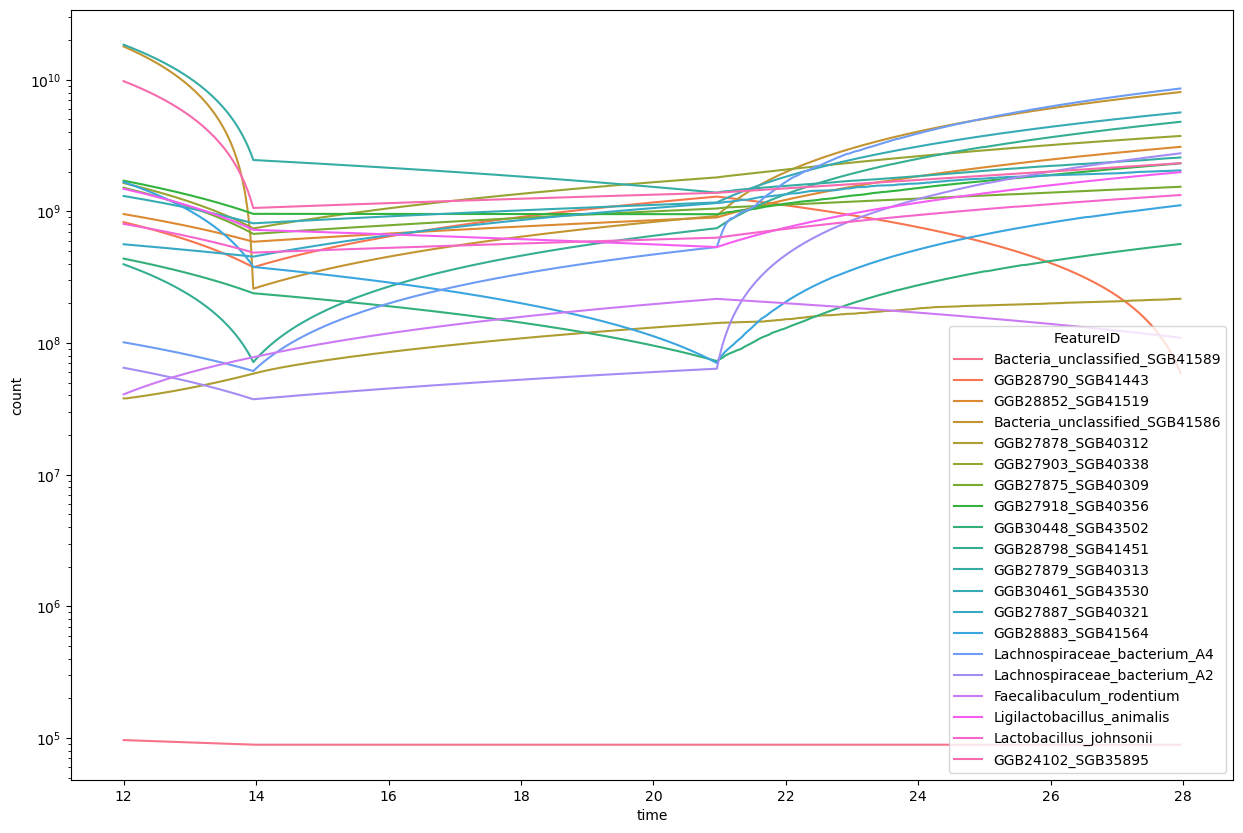

In [35]:
FBA_biomass = np.zeros([len(model_abun_dict.keys()), len(model_abun_dict['Lactobacillus_johnsonii']['fba_biomass'])])
FBA_biomass

# %%
### Convert FBA abun output to relative abundance 
count = 0
for key in model_abun_dict:
    FBA_biomass[count,:] = model_abun_dict[key]['fba_biomass']
    count+=1

FBA_biomass_df = pd.DataFrame(FBA_biomass)
FBA_biomass_df.index = model_abun_dict.keys()

index_to_filter_by = FBA_biomass_df.index

## Tranform to relative abun

FBA_biomass_df = FBA_biomass_df/FBA_biomass_df.sum(axis=0)

### Need to just add the missing bug for now to the FBA output 
#FBA_biomass_df = FBA_biomass_df.T
#FBA_biomass_df['9cf5cb71450a2aa080ff905f89b0a624'] = 0
#FBA_biomass_df = FBA_biomass_df.T

FBA_biomass_df = FBA_biomass_df.melt(ignore_index=False)
FBA_biomass_df = FBA_biomass_df.reset_index()
FBA_biomass_df.columns = ['FeatureID','time', 'count']
FBA_biomass_df['time'] = ((FBA_biomass_df['time']/time_scaler))+12.0
FBA_biomass_df

# %%
FBA_biomass_df_plot = pd.DataFrame(FBA_biomass)
FBA_biomass_df_plot.index = model_abun_dict.keys()

FBA_biomass_df_plot = FBA_biomass_df_plot.melt(ignore_index=False)
FBA_biomass_df_plot = FBA_biomass_df_plot.reset_index()
FBA_biomass_df_plot.columns = ['FeatureID','time', 'count']
FBA_biomass_df_plot['time'] = (FBA_biomass_df_plot['time']/time_scaler) + 12.0
FBA_biomass_df_plot['count'] = FBA_biomass_df_plot['count']*scal_fact

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=FBA_biomass_df_plot, x='time', y='count', hue = 'FeatureID')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abundances_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

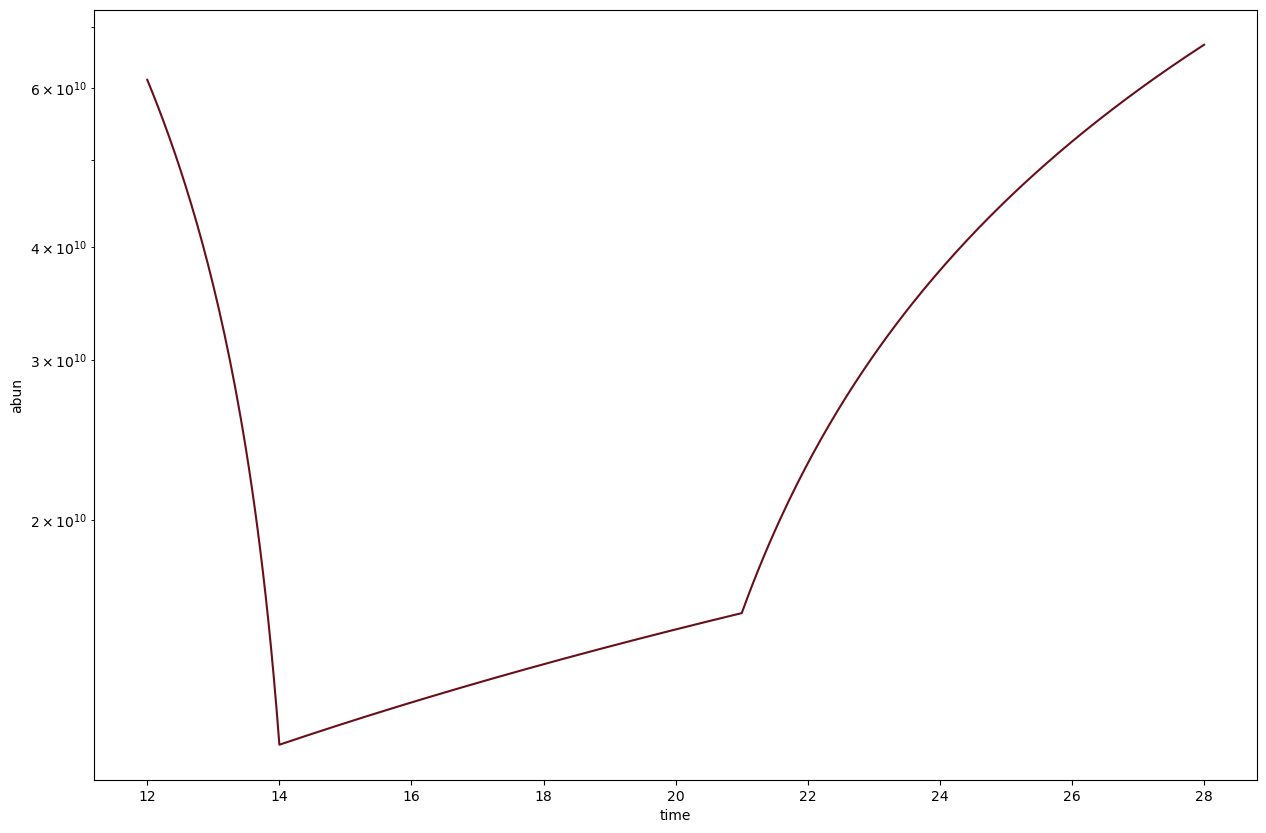

In [51]:
    FBA_biomass_df_plot

    FBA_biomass_df_plot_unstack = FBA_biomass_df_plot.pivot(index='FeatureID', columns ='time')['count']
    FBA_biomass_df_plot_unstack = pd.DataFrame(FBA_biomass_df_plot_unstack.sum(axis=0)).reset_index()
    FBA_biomass_df_plot_unstack.columns = ['time', 'abun']
    FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])
    FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])

    # %%
    ### Need to plot metabolite trajectories too

    met_pool_over_time_df = pd.DataFrame(met_pool_over_time)
    met_pool_over_time_df = met_pool_over_time_df.fillna(0)
    met_pool_over_time_df_melt= met_pool_over_time_df.melt(ignore_index=False)
    met_pool_over_time_df_melt = met_pool_over_time_df_melt.reset_index()
    met_pool_over_time_df_melt.columns = ['Time','Metabolite', 'Concentration']
    met_pool_over_time_df_melt

    # %%f
    met_pool_over_time_df

    # %%
    met_pool_over_time_df_melt[met_pool_over_time_df_melt['Concentration'] < 0]

    # %%
    met_pool_over_time_df_melt[met_pool_over_time_df_melt['Metabolite'] == 'EX_adn(e)']

    # %%
    total_abun_MDSINE = pd.DataFrame(abun_df.sum(axis=0)).reset_index()
    total_abun_MDSINE.columns = ['time', 'abun']
    total_abun_MDSINE['time'] = (pd.to_numeric(total_abun_MDSINE['time']))#/24.0)+12.0
    total_abun_MDSINE.head()

    # %%
    fig, axs = plt.subplots(figsize= (15,10))
    sns.lineplot(data=total_abun_MDSINE, x='time', y='abun')
    plt.yscale('log')
    plt.show()

    # %%
    output_folder = 'filtering_hourly_resolution'

    #plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num)



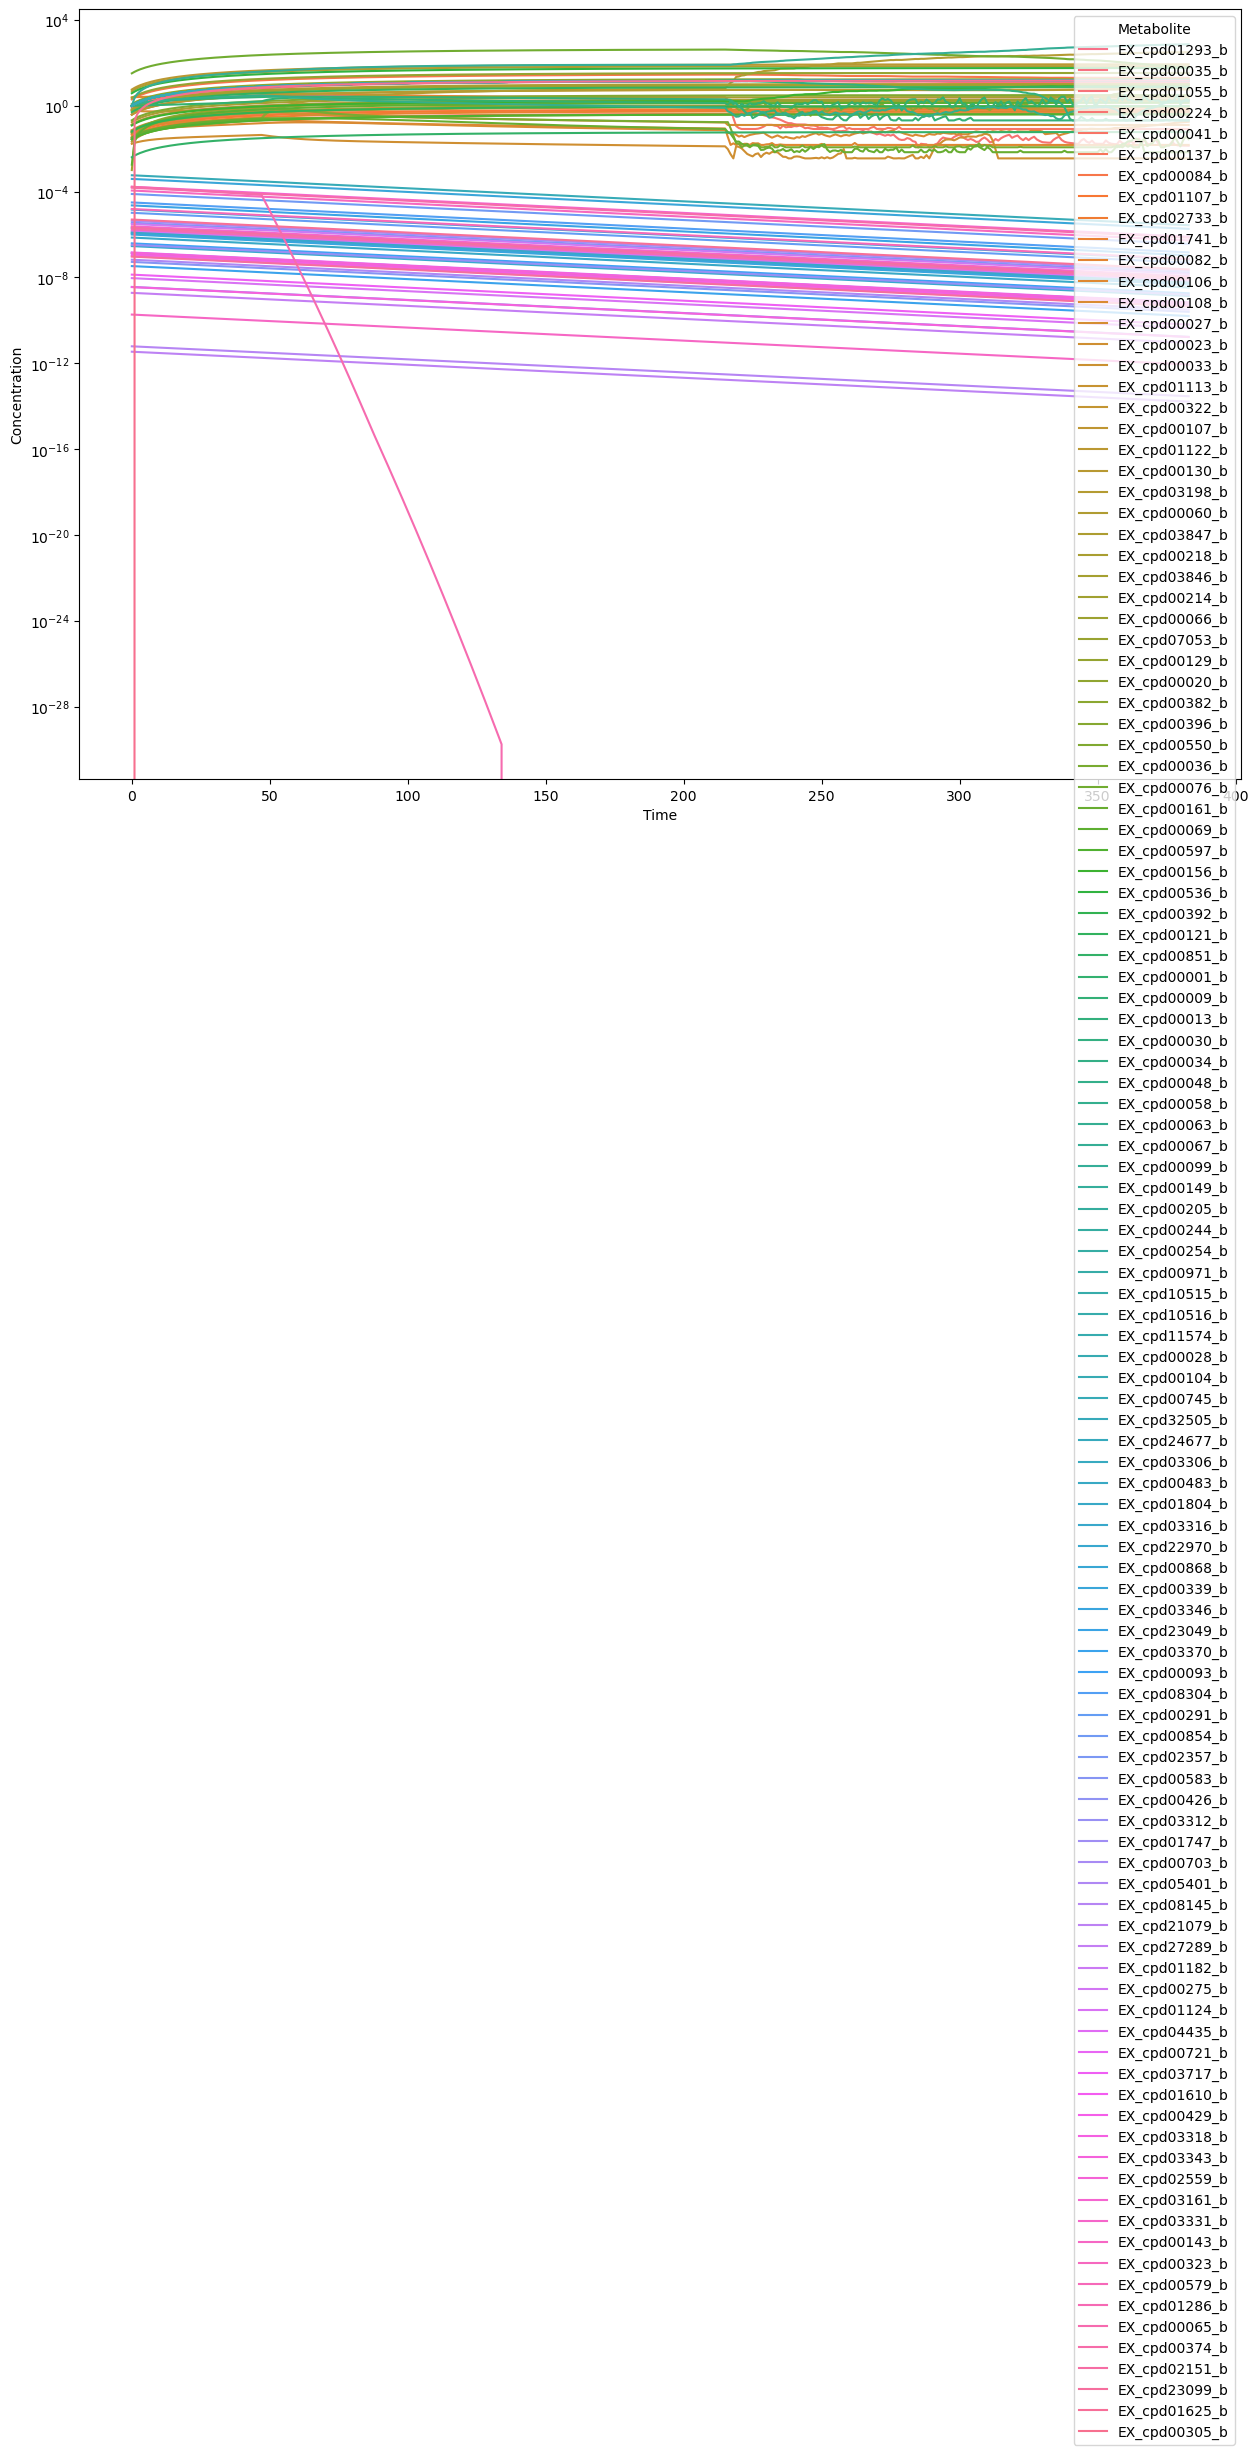

In [52]:
plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

                                     AZ5M7       AZ5R1      AZ5R14  \
GGB27903_SGB40338               2081410688  1118520852  1640669789   
GGB24102_SGB35895                644500306   742677997   718616627   
GGB30448_SGB43502                250787670    81050322           0   
GGB27918_SGB40356                683728970   592490485   452338012   
GGB28790_SGB41443                        0      818732   786964851   
Bacteria_unclassified_SGB41586   152945411    50439209   361192683   
GGB27879_SGB40313               1543271445  1363533479   703167718   
GGB30461_SGB43530                222287493    56613744  1047052514   
GGB27878_SGB40312                968836141           0   723133266   
GGB28798_SGB41451                180304788   159153707   893728367   
GGB27875_SGB40309                372000223   345781438   622060563   
Muribaculaceae_bacterium         402517881   184429776           0   
GGB28883_SGB41564                  8136884    72474394           0   
GGB27887_SGB40321   

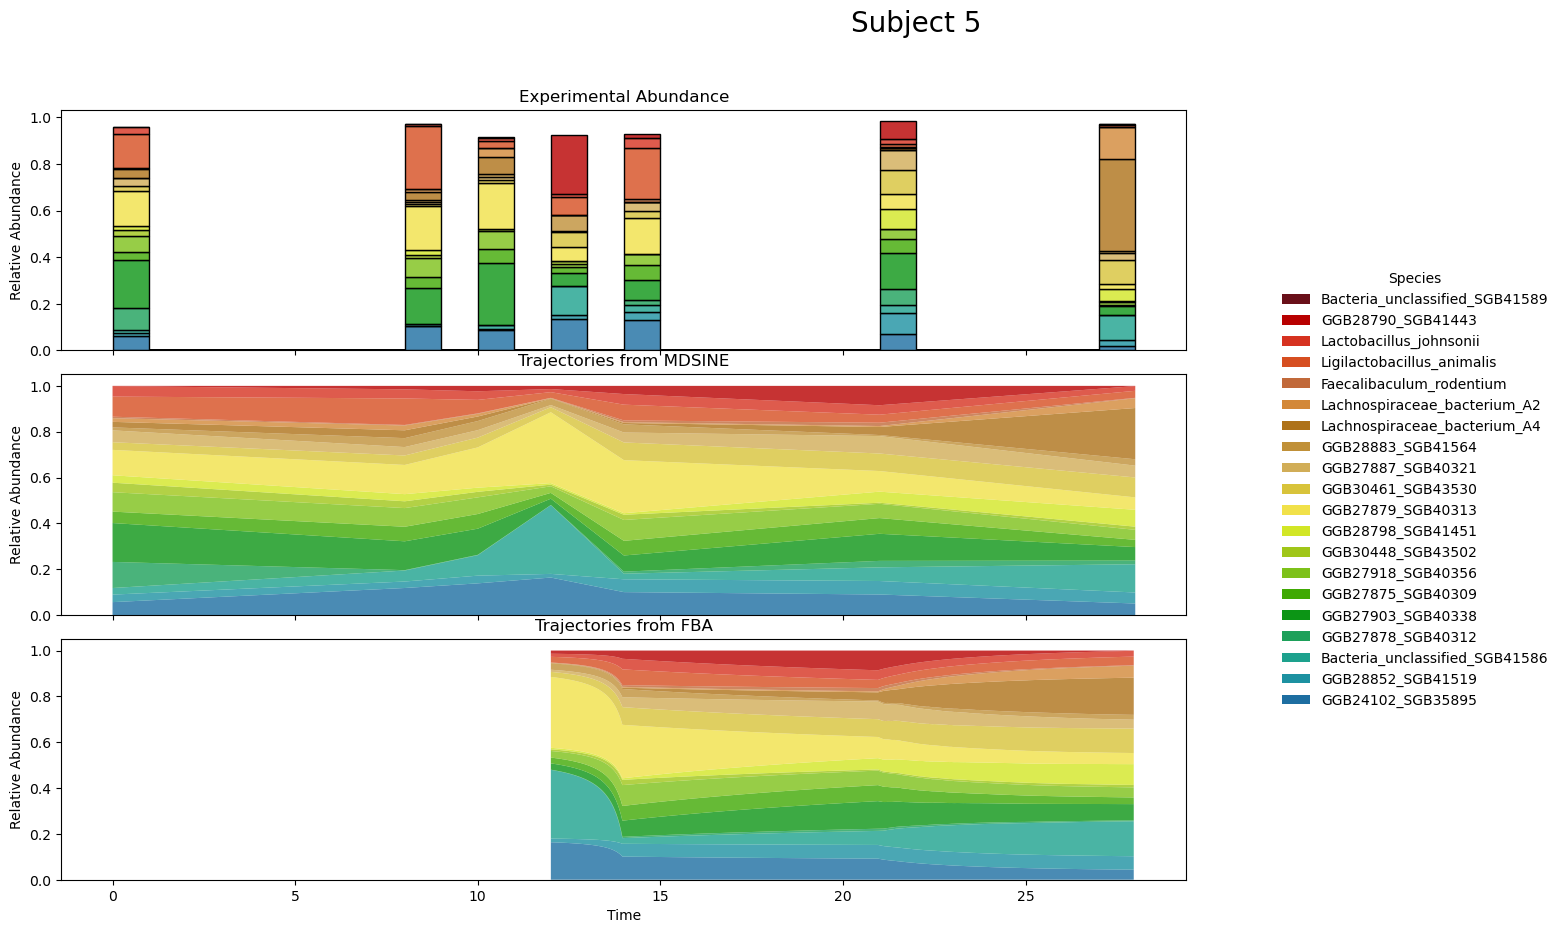

In [53]:
samps_for_sub = {}


temp = metadata[metadata['subject'] == subject_to_plot]
testing = counts.filter(temp.index.tolist(), axis=1)
print(testing)
testing = testing.loc[~(testing==0).all(axis=1)]
qpcr_measurements = qpcr.reindex(testing.columns)
qpcr_measurements = qpcr_measurements['measurement1'].to_list()
testing_ra = testing.reindex(index_to_filter_by)
testing_ra = testing/testing.sum(axis=0)
testing_abs_abun = testing_ra*qpcr_measurements
time_dict = dict(zip(temp.index, temp['time'].tolist()))
testing_melt_ra = testing_ra.melt(ignore_index=False)
testing_melt_ra.columns = ['sample', 'count']
testing_melt_ra['time'] = testing_melt_ra['sample'].map(time_dict)
#print(testing_melt_ra.head())
testing_melt_abs_abun = testing_abs_abun.melt(ignore_index=False)
testing_melt_abs_abun.columns = ['sample', 'count']
testing_melt_abs_abun['time'] = testing_melt_abs_abun['sample'].map(time_dict)

testing_melt_ra = testing_melt_ra.reset_index()
testing_melt_ra.columns = ['FeatureID', 'sample', 'count', 'time']

# load in MDSINE output for each subject 
output_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/AD_5xFAD_MDSINE_FBA/MDSINE2_data/5xfad_ctl_only/merged_studies_fixed_cluster_10000_its/posterior/filtering/Subject_' + str(subject_to_plot) + '/mean.tsv'
MDSINE_output = pd.read_csv(output_path, delimiter='\t', index_col=0)


MDSINE_output = MDSINE_output.reindex(index_to_filter_by)

MDSINE_output = MDSINE_output/MDSINE_output.sum(axis=0)
MDSINE_output = MDSINE_output.melt(ignore_index=False)
MDSINE_output = MDSINE_output.reset_index()
MDSINE_output.columns = ['FeatureID','time', 'count']


###################
### Second plot ###
###################

fig, (ax_top, ax_middle, ax_bottom) = plt.subplots(
3, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
)

# Ensure time is numeric
MDSINE_output['time'] = pd.to_numeric(MDSINE_output['time'])
testing_melt_ra['time'] = pd.to_numeric(testing_melt_ra['time'])
FBA_biomass_df['time'] = pd.to_numeric(FBA_biomass_df['time'])

# Define stacking order
feature_order = MDSINE_output['FeatureID'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot

# Assign consistent colors


twentysiz = [
    "#690f19", "#b80000", "#d63220", "#d64e20", "#c1693a",  # reds/oranges
    "#d38838", "#AE7219", "#C09038", "#d1ad57", "#d8c33a", "#f1e149",  # orange/yellows
    "#d2e626", "#a0c618", "#7dc119", "#40a903", "#0c9515",  # yellow/green
    "#1da05a", "#1da18d", "#1d91a1", "#1d6ea1", "#1d31a1",  # green/blue
    "#1a1a87", "#5b5bc9", "#8d8df1", "#8670cc", "#9870cc",  # blue/purple
    "#000000"  # black
]
#sns.set_style("dark")  # or "whitegrid", "dark", etc.
#sns.set_context("notebook")  # or "paper", "talk", "poster"
sns.set_palette(twentysiz)

#palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, twentysiz))

# Pivot for stackplot in reversed stacking order
continuous_pivot_MDSINE = (
    MDSINE_output
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]

# Pivot for stackplot in reversed stacking order
continuous_pivot_FBA = (
    FBA_biomass_df
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]



# Set categorical order for histogram
testing_melt_ra['FeatureID'] = pd.Categorical(testing_melt_ra.reset_index()['FeatureID'], categories=feature_order, ordered=True)

print(testing_melt_ra[testing_melt_ra['time'] == 0.0]['count'].sum())
print(testing_melt_ra[testing_melt_ra['time'] == 10.0]['count'].sum())
print(testing_melt_ra[testing_melt_ra['time'] == 12.0]['count'].sum())
# Top: histogram
sns.histplot(
    data=testing_melt_ra,
    x='time',
    weights='count',
    hue='FeatureID',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)

ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Middle: stackplot using reversed order and matching colors
ax_middle.stackplot(
    continuous_pivot_MDSINE.index,
    *[continuous_pivot_MDSINE[col] for col in continuous_pivot_MDSINE.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_middle.set_ylabel('Relative Abundance')
#ax_middle.set_xlabel('Time')
ax_middle.set_title('Trajectories from MDSINE')

# Bottom: stackplot using FBA output 

# Bottom: stackplot using reversed order and matching colors
ax_bottom.stackplot(
    continuous_pivot_FBA.index,
    *[continuous_pivot_FBA[col] for col in continuous_pivot_FBA.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_bottom.set_ylabel('Relative Abundance')
ax_bottom.set_xlabel('Time')
ax_bottom.set_title('Trajectories from FBA')



# Tidy layout
ax_top.tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1, right=0.75)



# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=feat)
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Species',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
second_plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_stacked_hist_line_plots_FBA_' + str(test_num) + '.pdf'
plt.savefig(second_plot_file_name, bbox_inches="tight")
plt.show()
plt.close()


In [54]:
testing_melt_abs_abun = testing_melt_abs_abun.reset_index()
testing_melt_abs_abun.columns = ['FeatureID', 'sample', 'count', 'time']
#testing_melt_abs_abun.reset_index().pivot(index='FeatureID', columns ='time')['count']

In [55]:
testing_melt_abs_abun_unstack = testing_melt_abs_abun.reset_index().pivot(index='FeatureID', columns ='time')['count']
testing_melt_abs_abun_unstack = pd.DataFrame(testing_melt_abs_abun_unstack.sum(axis=0)).reset_index()
testing_melt_abs_abun_unstack.columns = ['time', 'abun']
testing_melt_abs_abun_unstack['time'] = pd.to_numeric(testing_melt_abs_abun_unstack['time'])
testing_melt_abs_abun_unstack

,time,abun
0,0,1.168068e+10
1,8,8.029441e+09
2,10,1.206148e+10
3,12,6.411775e+10
4,14,1.114344e+10
5,21,1.459519e+10
6,28,6.763617e+10


In [56]:
total_abun_MDSINE

,time,abun
0,12.000000,6.126465e+10
1,12.041667,6.022316e+10
2,12.083333,5.918168e+10
3,12.125000,5.814019e+10
4,12.166667,5.709871e+10
...,...,...
380,27.833333,6.577181e+10
381,27.875000,6.607676e+10
382,27.916667,6.638171e+10
383,27.958333,6.668665e+10


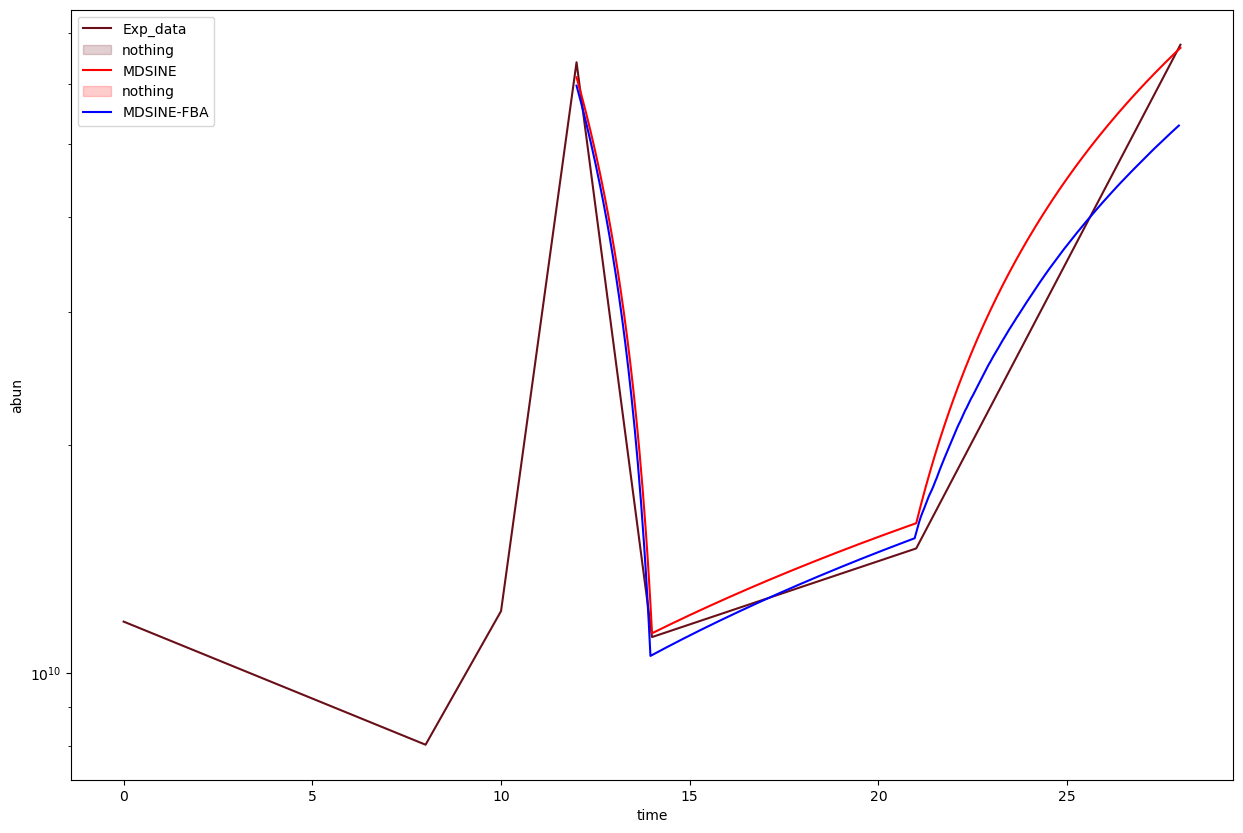

In [57]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=testing_melt_abs_abun_unstack, x='time', y='abun')
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun', color = 'red')
sns.lineplot(data=FBA_biomass_df_plot_unstack, x='time', y='abun', color = 'blue')
plt.legend(['Exp_data', 'nothing', 'MDSINE', 'nothing', 'MDSINE-FBA'])
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_comparison_abs_abun_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [43]:
met_pool_over_time_df = pd.DataFrame(met_pool_over_time)
met_pool_over_time_df = met_pool_over_time_df.fillna(0)
met_pool_over_time_df_melt= met_pool_over_time_df.melt(ignore_index=False)
met_pool_over_time_df_melt = met_pool_over_time_df_melt.reset_index()
met_pool_over_time_df_melt.columns = ['Time','Metabolite', 'Concentration']
met_pool_over_time_df_melt


,Time,Metabolite,Concentration
0,0,EX_cpd01293_b,0.131000
1,1,EX_cpd01293_b,0.156472
2,2,EX_cpd01293_b,0.181591
3,3,EX_cpd01293_b,0.206360
4,4,EX_cpd01293_b,0.230786
...,...,...,...
43771,379,EX_cpd00305_b,14.908960
43772,380,EX_cpd00305_b,14.909971
43773,381,EX_cpd00305_b,14.910989
43774,382,EX_cpd00305_b,14.912017


In [44]:
met_pool_over_time_df

,EX_cpd01293_b,EX_cpd00035_b,EX_cpd01055_b,EX_cpd00224_b,EX_cpd00041_b,EX_cpd00137_b,EX_cpd00084_b,EX_cpd01107_b,EX_cpd02733_b,EX_cpd01741_b,...,EX_cpd00143_b,EX_cpd00323_b,EX_cpd00579_b,EX_cpd01286_b,EX_cpd00065_b,EX_cpd00374_b,EX_cpd02151_b,EX_cpd23099_b,EX_cpd01625_b,EX_cpd00305_b
0,0.131000,0.836000,0.029000,0.055000,0.398000,1.046000,1.989000,0.046000,0.028000,0.038000,...,1.868500e-10,1.125619e-04,1.550699e-05,1.734231e-06,0.000168,1.517542e-04,2.075001e-06,9.382736e-08,5.011823e-06,0.000000
1,0.156472,0.998556,0.034639,0.065343,0.475389,1.249389,2.375744,0.054944,0.033444,0.045389,...,1.842549e-10,1.109985e-04,1.529161e-05,1.710145e-06,0.000166,1.496465e-04,2.046181e-06,9.252420e-08,4.942214e-06,0.208333
2,0.181591,1.158662,0.040199,0.075479,0.551703,1.449953,2.757116,0.063765,0.038813,0.052675,...,1.816958e-10,1.094569e-04,1.507923e-05,1.686393e-06,0.000163,1.475680e-04,2.017762e-06,9.123914e-08,4.873572e-06,0.413773
3,0.206360,1.316542,0.045683,0.085415,0.626957,1.647731,3.133191,0.072462,0.044108,0.059860,...,1.791722e-10,1.079366e-04,1.486979e-05,1.662971e-06,0.000160,1.455185e-04,1.989738e-06,8.997193e-08,4.805884e-06,0.616359
4,0.230786,1.472227,0.051090,0.095155,0.701166,1.842763,3.504043,0.081039,0.049328,0.066945,...,1.766837e-10,1.064375e-04,1.466327e-05,1.639874e-06,0.000157,1.434974e-04,1.962103e-06,8.872232e-08,4.739135e-06,0.816132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,1.955853,12.534646,0.432975,0.014359,0.082917,15.615968,19.973432,0.686788,0.418045,0.567347,...,9.319468e-13,5.614219e-07,7.734378e-08,8.649780e-09,0.000000,7.569002e-07,1.034943e-08,4.679802e-10,2.499734e-08,14.908960
380,1.955980,12.553570,0.433003,0.014011,0.082917,15.616997,20.040286,0.686833,0.418072,0.567383,...,9.190031e-13,5.536244e-07,7.626956e-08,8.529645e-09,0.000000,7.463877e-07,1.020569e-08,4.614805e-10,2.465015e-08,14.909971
381,1.956105,12.555755,0.433031,0.013879,0.082917,15.618011,20.105798,0.686877,0.418099,0.567420,...,9.062392e-13,5.459352e-07,7.521026e-08,8.411177e-09,0.000000,7.360212e-07,1.006394e-08,4.550711e-10,2.430779e-08,14.910989
382,1.956228,12.568139,0.433058,0.013823,0.082917,15.619010,20.034838,0.686920,0.418125,0.567456,...,8.936525e-13,5.383528e-07,7.416567e-08,8.294355e-09,0.000000,7.257986e-07,9.924162e-09,4.487506e-10,2.397018e-08,14.912017


In [45]:

### Prepare the simulation metabolomic data 

#met_pool_over_time_df_filt = met_pool_over_time_df.T.loc[agora_ex_ids_list]
#met_pool_over_time_df_filt = met_pool_over_time_df.T.loc[cmpd_names_adjust]
met_pool_over_time_df_filt = met_pool_over_time_df.reset_index()
met_pool_over_time_df_filt['index'] = (met_pool_over_time_df_filt['index']/time_scaler)
met_pool_over_time_df_filt = met_pool_over_time_df_filt.set_index('index').T
met_pool_over_time_df_filt_ra = met_pool_over_time_df_filt/met_pool_over_time_df_filt.sum(axis=0)
met_pool_over_time_df_filt_ra_melt = met_pool_over_time_df_filt_ra.melt(ignore_index=False).reset_index()
met_pool_over_time_df_filt_ra_melt.columns = ['metabolites', 'time', 'concentration']
met_pool_over_time_df_filt_ra_melt.head()
# use this to filter, agora_ex_ids_list

,metabolites,time,concentration
0,EX_cpd01293_b,0.0,0.001587
1,EX_cpd00035_b,0.0,0.010130
2,EX_cpd01055_b,0.0,0.000351
3,EX_cpd00224_b,0.0,0.000666
4,EX_cpd00041_b,0.0,0.004823


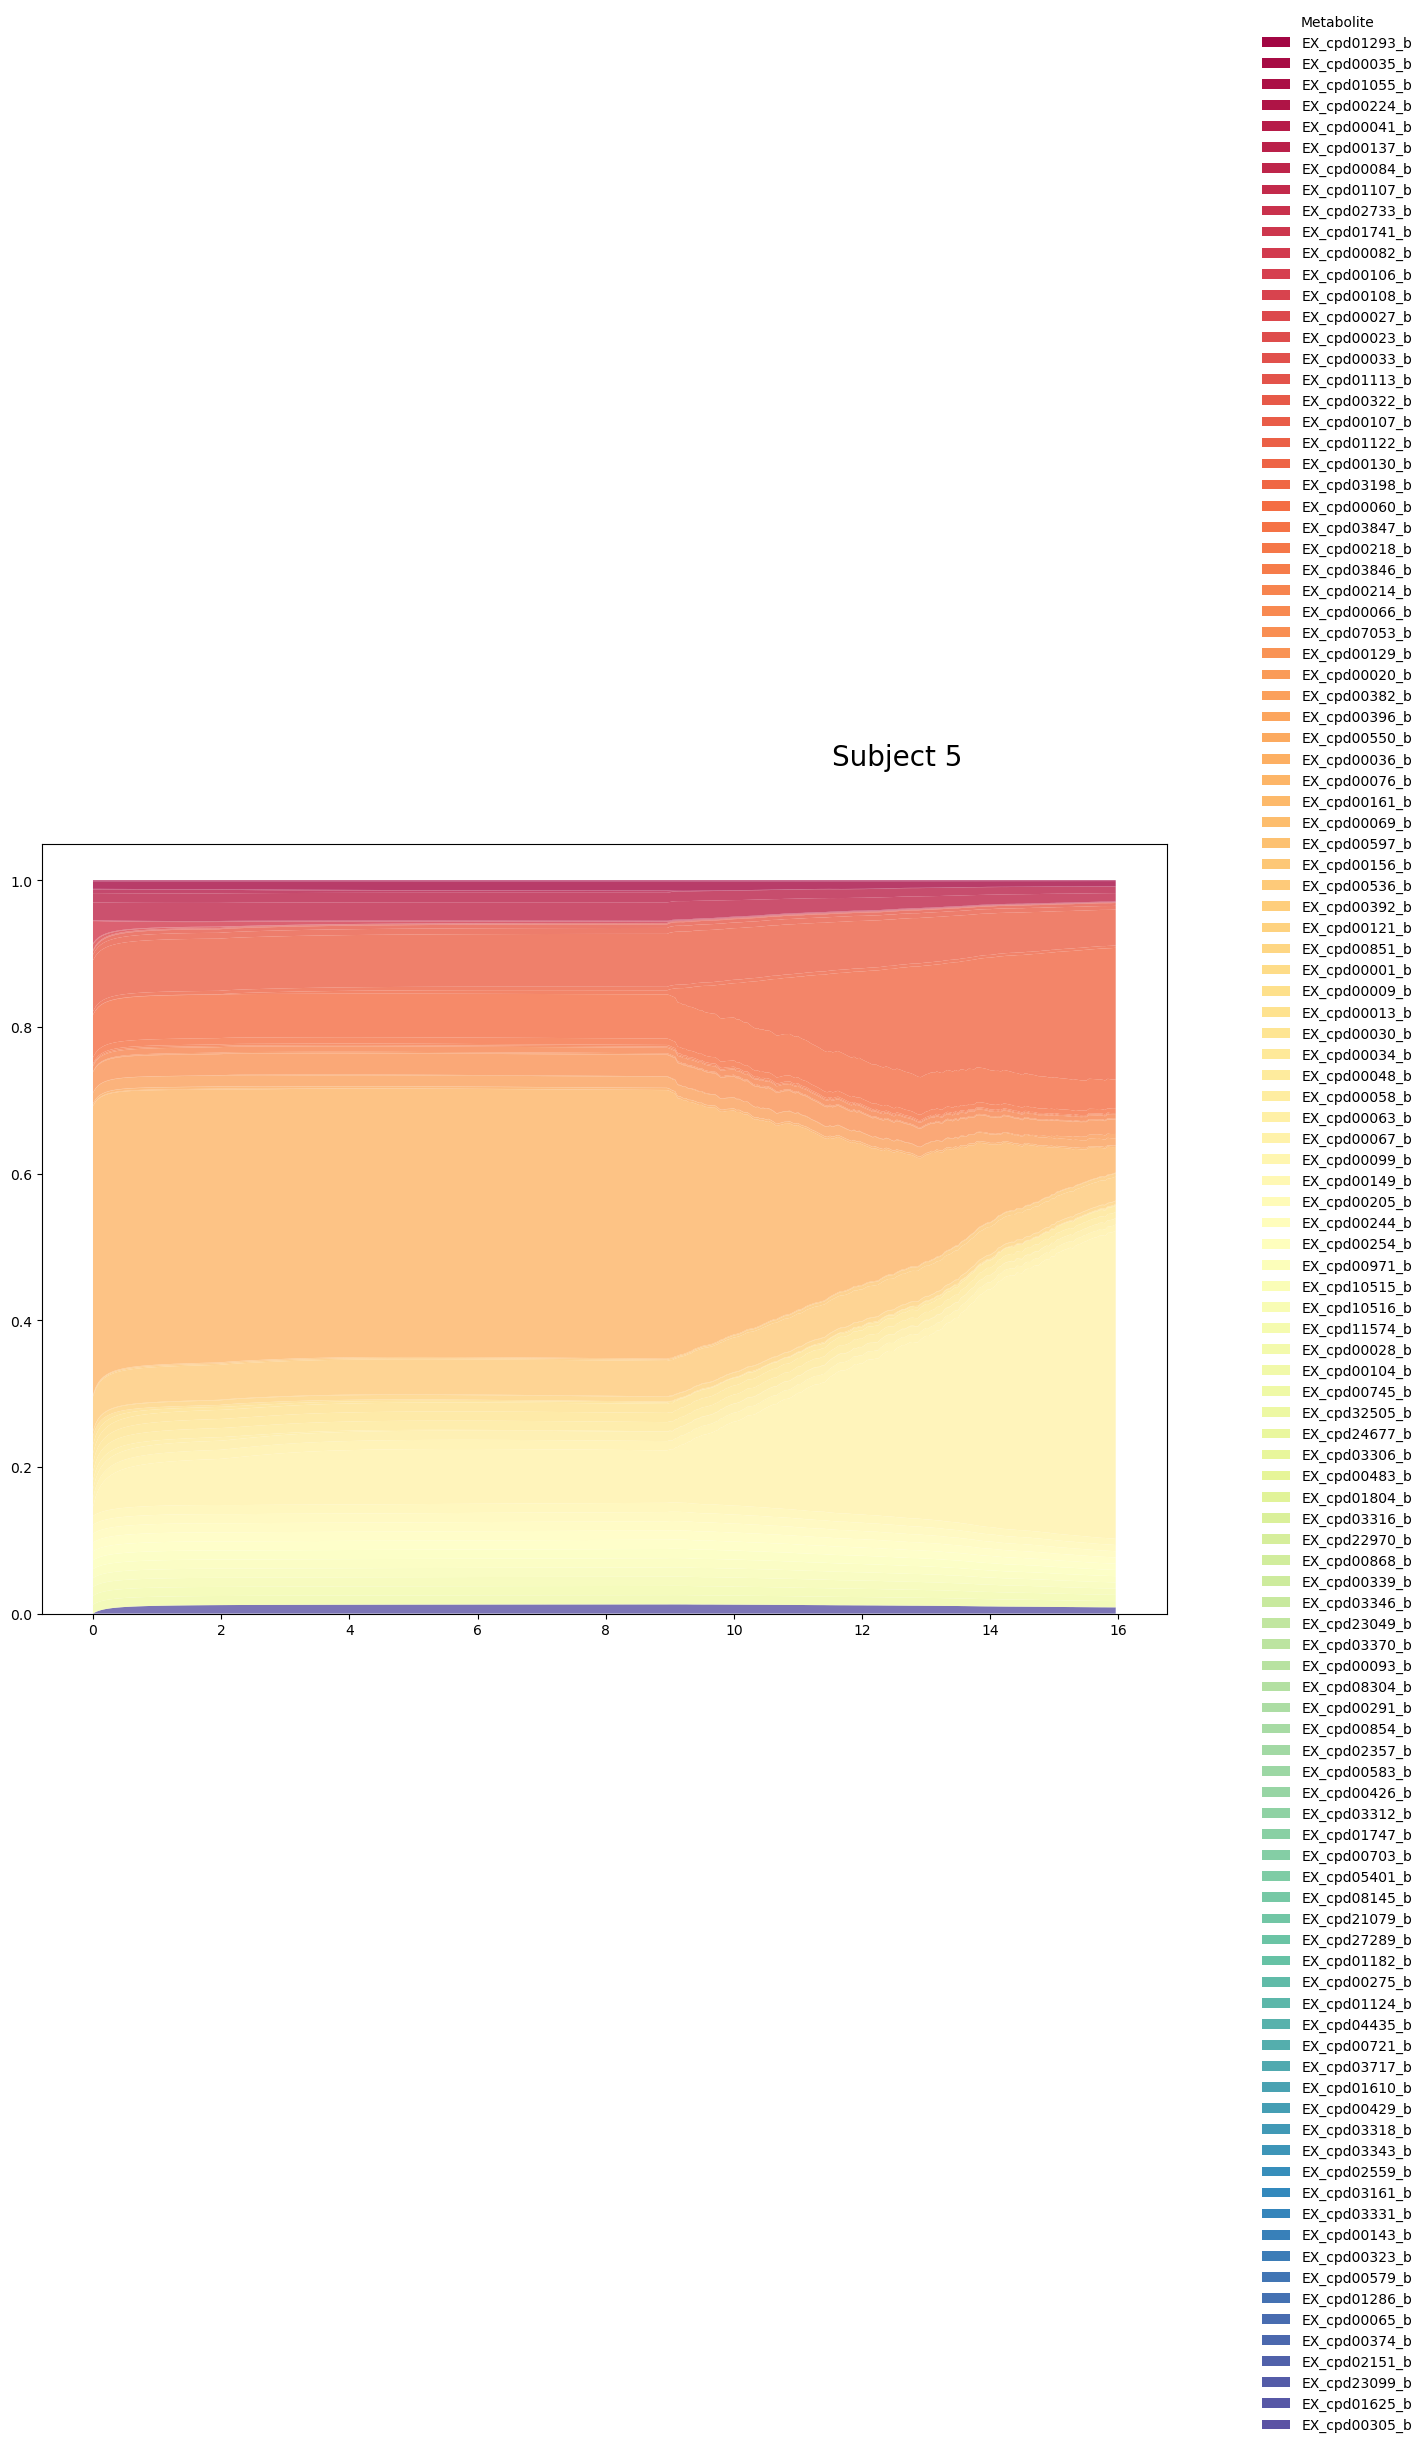

In [46]:
fig, (ax_bottom) = plt.subplots(
1, 1, figsize=(18, 10), sharex=True)

# Define stacking order
feature_order = met_pool_over_time_df.columns.tolist()
reversed_order = feature_order[::-1]  # For stackplot



palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, palette))

# Pivot for stackplot in reversed stacking order
met_pool_over_time_df_filt_ra_pivot = (
    met_pool_over_time_df_filt_ra_melt
    .pivot(index='time', columns='metabolites', values='concentration')
    .fillna(0)
)[reversed_order]

ax_bottom.stackplot(
    met_pool_over_time_df_filt_ra_pivot.index,
    *[met_pool_over_time_df_filt_ra_pivot[col] for col in met_pool_over_time_df_filt_ra_pivot.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)

# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=feat)
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_over_time_test_' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

51


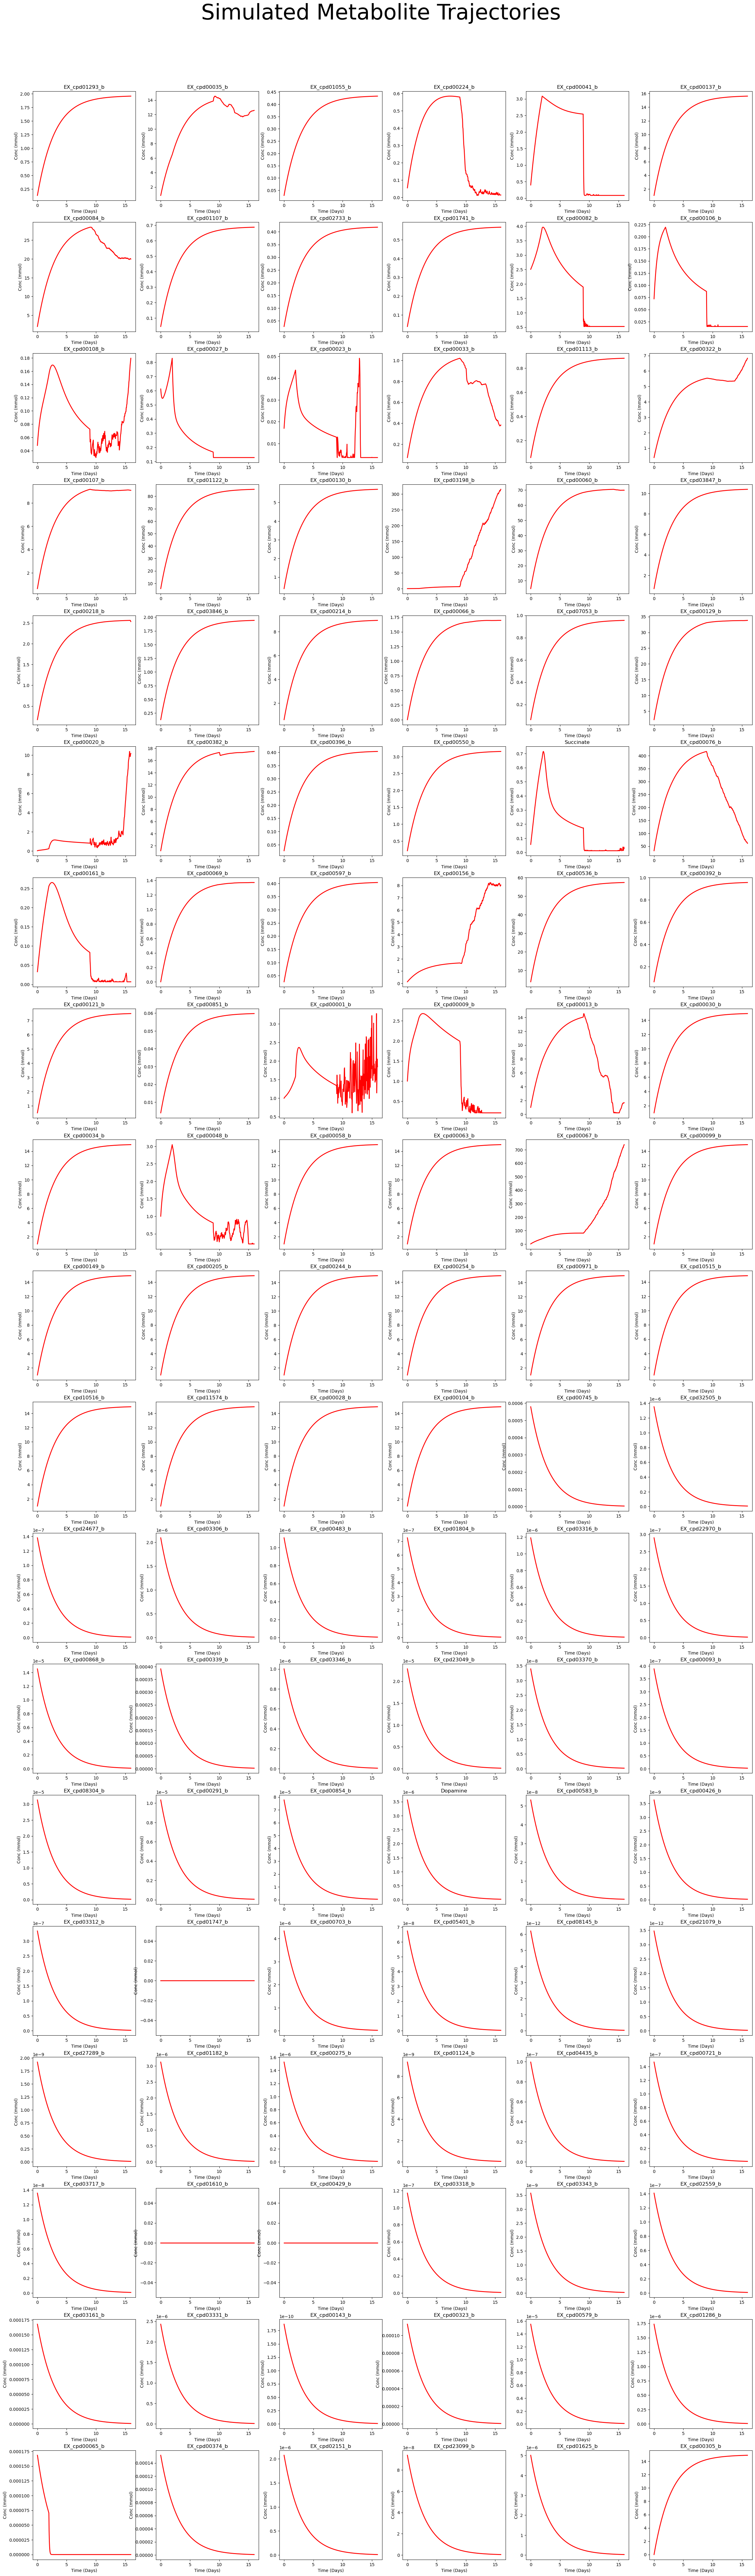

In [47]:
from scipy.signal import savgol_filter
num_plots = len(met_pool_over_time_df_filt.index.tolist())
cols = 6  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)#, sharey = True)
total_rmse = 0
# Flatten the axes array for easy iteration
axes = axes.flatten()
corr_dict = {}
rmse_dict = {}

count = 0

for i,met in enumerate(met_pool_over_time_df_filt.index.tolist()):
    temp_sim = met_pool_over_time_df_filt.loc[met,:]

    if met in cpds_to_filter_for:
        count += 1

    #temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    #temp_pearson_p_val_round = np.round(temp_pearson.pvalue,4)
    #corr_dict[met] = temp_pearson_stat_round
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'red', lw = 2)
    #sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
    #sns.scatterplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    #sns.lineplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    #sns.lineplot(ax=axes[i], x=temp_int.index.to_list(), y=temp_int.to_list(), color = 'green')
    if met == 'EX_cpd00036_b':
        met = 'Succinate'
    if met == 'EX_cpd00141_b':
        met = 'Propionate'
    if met == 'EX_cpd00211_b':
        met = 'Butyrate'
    if met == 'EX_cpd01022_b':
        met = 'Lactic acid'
    if met == 'EX_cpd00221_b':
        met = 'Lactic acid'    
    if met == 'EX_cpd00159_b':
        met = 'Lactic acid'
    if met == 'EX_cpd02357_b':
        met = 'Dopamine'

    axes[i].set_title(f"{met}") 
    axes[i].set_xlabel('Time (Days)')
    axes[i].set_ylabel('Conc (mmol)')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
if mets_used_for_constraint == 0:
    subtract = 0
else:
    subtract = len(mets_used_for_constraint)
#plt.subplots_adjust(hspace=.2)
#rmse_dict['total_rmse'] = total_rmse/(60-subtract)
plt.subplots_adjust(top=0.95)
plt.suptitle('Simulated Metabolite Trajectories', size = 50)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_sim_individual_scatterplots_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

print(count)

In [48]:
### Here put the start and final experimental conditions in a format such that it can be plotted easily with the simulated data 

final_exp_conditions['time'] = 16.0
init_exp_conditions['time'] = 0.0

start_end_exp_conds_combined = pd.concat([final_exp_conditions, init_exp_conditions])
start_end_exp_conds_combined

,reaction,fluxValue,time
0,EX_cpd00745_b,6.153236e-05,16.0
1,EX_cpd32505_b,1.195033e-06,16.0
2,EX_cpd24677_b,0.000000e+00,16.0
3,EX_cpd03306_b,9.129116e-07,16.0
4,EX_cpd00483_b,1.441348e-07,16.0
...,...,...,...
46,EX_cpd00374_b,1.517542e-04,0.0
47,EX_cpd00069_b,1.808502e-03,0.0
48,EX_cpd02151_b,2.075001e-06,0.0
49,EX_cpd23099_b,9.382736e-08,0.0


In [49]:
start_end_exp_conds_combined[start_end_exp_conds_combined['reaction'] == 'EX_cpd00745_b']

,reaction,fluxValue,time
0,EX_cpd00745_b,0.000062,16.0
0,EX_cpd00745_b,0.000579,0.0


51


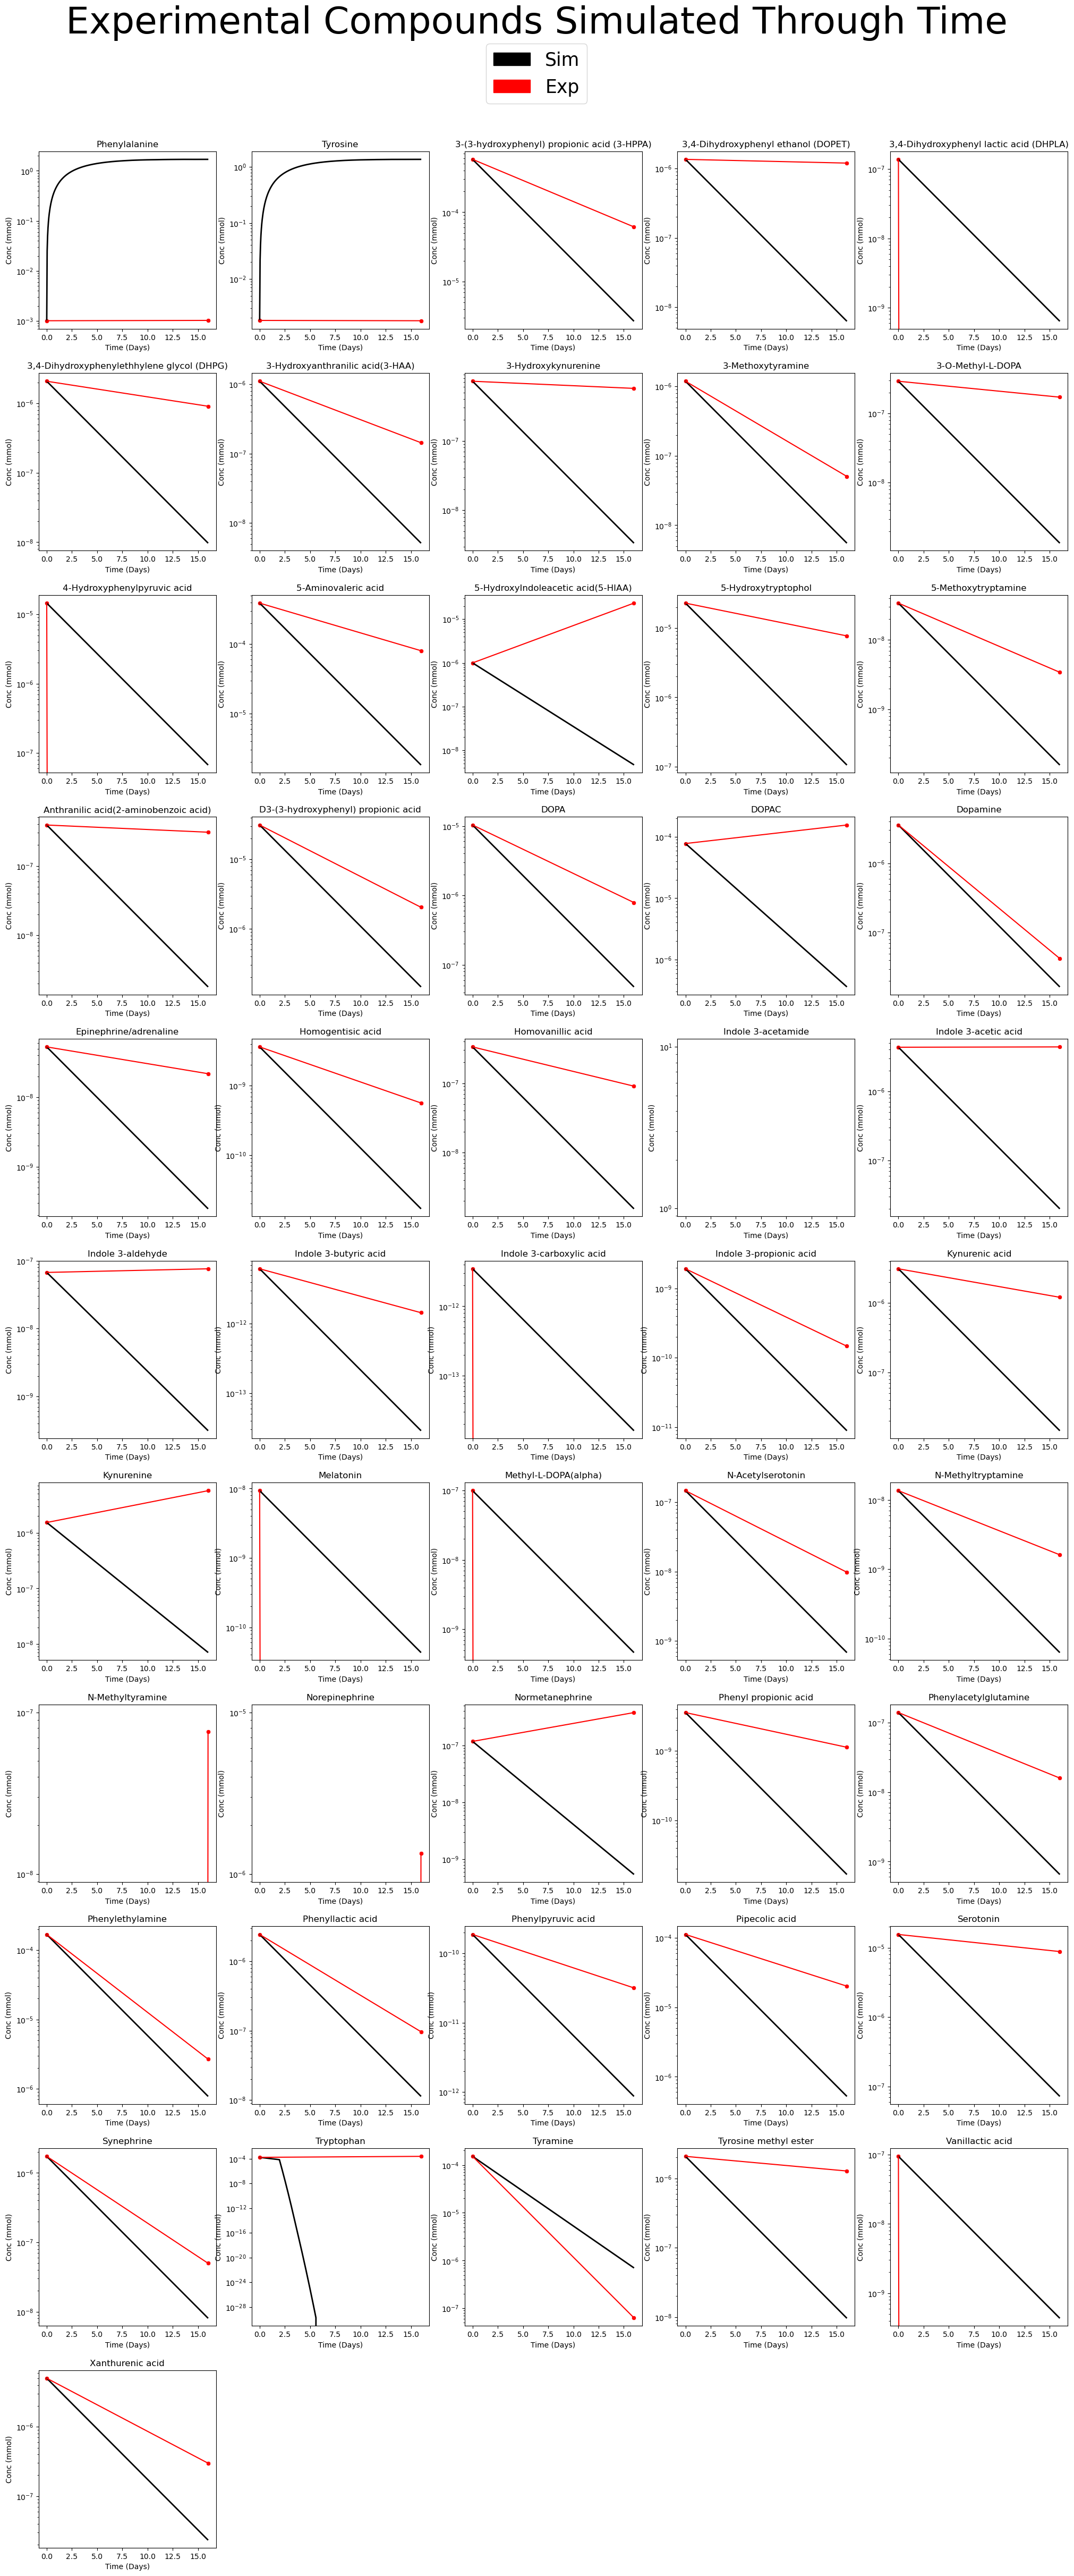

In [61]:
mets_to_plot = [met for met in met_pool_over_time_df_filt.index if met in cpds_to_filter_for]

num_plots = len(mets_to_plot)
cols = 5  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)#, sharey = True)
total_rmse = 0
# Flatten the axes array for easy iteration
axes = axes.flatten()
corr_dict = {}
rmse_dict = {}

count = 0

for i, met in enumerate(mets_to_plot):
    temp_sim = met_pool_over_time_df_filt.loc[met,:]
    temp_exp = start_end_exp_conds_combined[start_end_exp_conds_combined['reaction'] == met]

    if met in cpds_to_filter_for:
        count += 1

    #temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    #temp_pearson_p_val_round = np.round(temp_pearson.pvalue,4)
    #corr_dict[met] = temp_pearson_stat_round
        # Scatter plot on the respective subplot
        sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'black', lw = 2)
    #sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
        sns.scatterplot(ax=axes[i], data = temp_exp, x='time', y='fluxValue',color = 'red')
        sns.lineplot(ax=axes[i], data = temp_exp, x='time', y='fluxValue',color = 'red')
    #sns.lineplot(ax=axes[i], x=temp_int.index.to_list(), y=temp_int.to_list(), color = 'green')

    ### Translate met from kbase back to readable version from experimental data

    met_kbase = kbase_to_exp_mets_dict[met]
    
    axes[i].set_title(f"{met_kbase}") 
    axes[i].set_xlabel('Time (Days)')
    axes[i].set_ylabel('Conc (mmol)')
    axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
if mets_used_for_constraint == 0:
    subtract = 0
else:
    subtract = len(mets_used_for_constraint)
plt.suptitle('Experimental Compounds Simulated Through Time', size = 50)
# Create custom legend entries using Patch objects
sim_leg = mpatches.Patch(color='black', label='Sim')
exp_leg = mpatches.Patch(color='red', label='Exp')

# Add the custom patches to the legend
fig.legend(handles=[sim_leg, exp_leg], loc = 'upper center', bbox_to_anchor = (0.5,0.97), fontsize = 25)
#plt.tight_layout()
plt.subplots_adjust(top=0.93)


plt.subplots_adjust(hspace=.25)
#rmse_dict['total_rmse'] = total_rmse/(60-subtract)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_exp_filtered_mets_exp_vs_sim_individual_scatterplots_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

print(count)